# Phase 3: Reproducible Evaluation + Response Diff Analysis

This notebook implements the next phase based on your roadmap:
- deterministic cache keys
- fixed retrieval mapping
- unified hallucination thresholds
- quick/full sampling modes
- qualitative sample outputs per technique
- pairwise text diffs between techniques/models

In [1]:
%pip install -q transformers sentence_transformers datasets accelerate seaborn matplotlib pandas numpy rouge_score faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 80.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import re
import json
import time
import hashlib
import difflib
import string
import shutil
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import snapshot_download
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer
from IPython.display import display
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, GenerationConfig, pipeline

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Running on device: {device}')

Running on device: cuda


## 1) Global Configuration

In [3]:
DATA_DIR = '/kaggle/input/datasets/larbimohammedachraf/pfe-rarediease/'# Kaggle dataset input
_KAGGLE_DATA = "/kaggle/input/datasets/larbimohammedachraf/pfe-rarediease"
RAG_CORPUS_FILE = os.path.join(DATA_DIR, 'rag_corpus_final.jsonl')
PE_SFT_FILE     = os.path.join(DATA_DIR, 'pe_sft_final.jsonl')
EVAL_FILE       = os.path.join(DATA_DIR, 'eval_rare_cases.jsonl')
_PREV_RUN    = "/kaggle/input/notebooks/islemcharafeddine/base-pfe-open-pubmed/"
ON_KAGGLE    = os.path.isdir(_KAGGLE_DATA)

OUTPUT_DIR  = '/kaggle/working/output/'  # Kaggle working directory
CACHE_DIR   = os.path.join(OUTPUT_DIR, 'cache_llm')
CACHE_FILE  = os.path.join(CACHE_DIR, 'predictions_comparative_phase3.json')
WORK_DIR     = "/kaggle/working" if ON_KAGGLE else "data"

# ── Embedding models ───────────────────────────────────────────────────────────
# fast  : sentence-transformers/all-MiniLM-L6-v2
#         Wang et al. (2020) "Minilm: Deep self-attention distillation for task-agnostic
#         compression of pre-trained transformers", NeurIPS 2020.
#         384-dim, general-purpose, fast inference.
# biomed: NeuML/pubmedbert-base-embeddings
#         Derived from PubMedBERT (Gu et al., 2021 "Domain-Specific Language Model
#         Pretraining for Biomedical NLU", ACM HEALTH 2021).
#         768-dim, biomedical domain-specific.
IS_KAGGLE = os.path.exists('/kaggle')
EMBEDDING_MODEL_REGISTRY = {
    'fast':   'sentence-transformers/all-MiniLM-L6-v2',
    'biomed': 'NeuML/pubmedbert-base-embeddings',
}

DEFAULT_EMBEDDING_PROFILE     = 'biomed'
EMBEDDING_PROFILES_TO_COMPARE = ['fast', 'biomed']
ENABLE_EMBEDDING_COMPARISON   = False  # Use only one embedding model

EMBEDDING_BATCH_SIZES = {
    'fast':   128,
    'biomed':  64,
}

HF_CACHE_DIR    = os.path.join(OUTPUT_DIR, 'hf_cache')

# ── FAISS index ──────────────────────────────────────────────────────────────
FAISS_INDEX_DIR = os.path.join(WORK_DIR, "faiss_index")
os.makedirs(FAISS_INDEX_DIR, exist_ok=True)
_PREV_FAISS = os.path.join(_PREV_RUN, "faiss_index")
if ON_KAGGLE and os.path.isdir(_PREV_FAISS):
    import shutil
    for f in os.listdir(_PREV_FAISS):
        src, dst = os.path.join(_PREV_FAISS, f), os.path.join(FAISS_INDEX_DIR, f)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
    print(f"✅ Reused FAISS index from previous run")

Path(FAISS_INDEX_DIR).mkdir(parents=True, exist_ok=True)
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
Path(HF_CACHE_DIR).mkdir(parents=True, exist_ok=True)
os.environ.setdefault('HF_HOME', HF_CACHE_DIR)

# ── LLM models ────────────────────────────────────────────────────────────────
# ⚠️  OpenBioLLM-8B is GATED (Meta Llama-3 license).
#     Accept the license at huggingface.co/aaditya/Llama3-OpenBioLLM-8B
#     then add HF_TOKEN to Kaggle Secrets (Add-ons → Secrets → HF_TOKEN).
#
# OpenBioLLM-8B : aaditya/Llama3-OpenBioLLM-8B
#   Pal (2024) "OpenBioLLMs: Advancing Open-Source Large Language Models for
#   Healthcare and Life Sciences". Based on Meta Llama-3-8B-Instruct (Dubey et al.,
#   2024). Fine-tuned on curated biomedical corpora. Context: 8192 tokens.
#
# BioMistral-7B : BioMistral/BioMistral-7B
#   Labrak et al. (2024) "BioMistral: A Collection of Open-Source Pretrained Large
#   Language Models for Medical Domains", ACL Findings 2024.
#   Based on Mistral-7B-v0.1 (Jiang et al., 2023). Context: 4096 tokens.
MODEL_REGISTRY = {
    'OpenBioLLM': 'aaditya/Llama3-OpenBioLLM-8B',
    'BioMistral':  'BioMistral/BioMistral-7B',
}
MODELS_TO_TEST = ['OpenBioLLM']

# ── Evaluation thresholds ─────────────────────────────────────────────────────
THRESHOLDS = {
    'cosine_correct': 0.65,   # FIXED: was 0.75 — rare disease name variants are 0.65-0.80 in biomed space,
    'cosine_partial': 0.25,  # FIXED: was 0.30,
    'f1_partial':     0.10   # FIXED: was 0.15,
}

# ── Retrieval settings ────────────────────────────────────────────────────────
# Standard RAG, Self-RAG, Speculative-RAG: retrieve with RETRIEVAL_MIN_SCORE (0.35)
# Corrective-RAG: retrieves with looser CRAG_RETRIEVE_SCORE (0.20) first,
#                 then the CRAG algorithm classifies and filters internally.
RETRIEVAL_MIN_SCORE = 0.25   # FIXED: was 0.35 — caused [No passages] for many rare disease queries   # minimum cosine for RAG / Self-RAG / Speculative-RAG
RETRIEVAL_TOP_K     = 10  # FIXED: was 5 — more docs for better coverage

# CRAG-specific thresholds — Yan et al. (2024) ICLR 2024
# The paper defines three confidence categories for retrieved documents:
#   score ≥ CRAG_CORRECT_SCORE  → CORRECT  (use as evidence directly)
#   CRAG_AMBIGUOUS_MIN ≤ score < CRAG_CORRECT_SCORE → AMBIGUOUS (combine with knowledge)
#   score < CRAG_AMBIGUOUS_MIN  → INCORRECT (discard; reason from parametric knowledge)
CRAG_RETRIEVE_SCORE = 0.20   # initial retrieval threshold for CRAG (wider net before filter)
CRAG_CORRECT_SCORE  = 0.60   # ≥ this → CORRECT retrieval
CRAG_AMBIGUOUS_MIN  = 0.35   # ≥ this and < CRAG_CORRECT_SCORE → AMBIGUOUS

# -- Cross-Encoder Reranker (ported from advanced notebook) ----------------
# Reference: Nogueira & Cho (2020) "Passage Re-ranking with BERT"
# MedCPT-Cross-Encoder: biomedical cross-encoder trained on PubMed queries.
RERANKER_ENABLED = True
RERANKER_TOP_N   = 18
RERANKER_MODEL_CANDIDATES = [
    'ncbi/MedCPT-Cross-Encoder',
    'cross-encoder/ms-marco-MiniLM-L-6-v2',
]

# ── Prompt techniques ─────────────────────────────────────────────────────────
# All technique references are documented in detail in build_prompt() (Cell 4).
#
# RAG family (4 techniques, each compared across both embedding profiles):
#   rag              : Lewis et al. (2020) NeurIPS
#   self-rag         : Asai et al. (2023) ICLR 2024 — [IsREL]/[IsSUP]/[IsUSE] reflection
#   corrective-rag   : Yan et al. (2024) ICLR 2024  — CORRECT/AMBIGUOUS/INCORRECT routing
#   speculative-rag  : Shi et al. (2024)             — draft (subset) → verify (all docs)
#
# react: Yao et al. (2023) ICLR — true interactive ReAct with dynamic FAISS search
#         (model dynamically decides when and what to search)
RAG_RETRIEVAL_TYPES = ['rag', 'self-rag', 'corrective-rag', 'speculative-rag', 'react']

PROMPTS_TO_TEST = ['zero-shot', 'few-shot', 'cot', 'rag', 'self-rag', 'corrective-rag', 'speculative-rag', 'react']
TECHNIQUE_NAMES = {
    'zero-shot':       'Zero-Shot',
    'few-shot':        'Few-Shot (ICL)',
    'cot':             'CoT',
    'rag':             'RAG',
    'self-rag':        'Self-RAG',
    'corrective-rag':  'Corrective-RAG',
    'speculative-rag': 'Speculative-RAG',
    'react':           'ReAct',
}

# ── Sampling policy ───────────────────────────────────────────────────────────
EVAL_MODE         = 'quick_debug_sample'   # quick_debug_sample | full_eval
QUICK_SAMPLE_SIZE = 200
QUICK_SAMPLE_SEED = 42
QUAL_CASES        = 5
QUAL_SEED         = 42

print(f'Default embedding profile : {DEFAULT_EMBEDDING_PROFILE}')
print(f'Embedding comparison      : {ENABLE_EMBEDDING_COMPARISON} — profiles: {EMBEDDING_PROFILES_TO_COMPARE}')
print(f'Models to test            : {MODELS_TO_TEST}')
print(f'Prompt techniques         : {PROMPTS_TO_TEST}')
print(f'RAG retrieval types       : {RAG_RETRIEVAL_TYPES}')
print(f'Eval mode                 : {EVAL_MODE} | n={QUICK_SAMPLE_SIZE} | seed={QUICK_SAMPLE_SEED}')
print(f'Thresholds                : {THRESHOLDS}')
print(f'Retrieval                 : top_k={RETRIEVAL_TOP_K} | min_score={RETRIEVAL_MIN_SCORE}')
print(f'CRAG thresholds           : retrieve={CRAG_RETRIEVE_SCORE} | correct={CRAG_CORRECT_SCORE} | ambiguous_min={CRAG_AMBIGUOUS_MIN}')


✅ Reused FAISS index from previous run
Default embedding profile : biomed
Embedding comparison      : False — profiles: ['fast', 'biomed']
Models to test            : ['OpenBioLLM']
Prompt techniques         : ['zero-shot', 'few-shot', 'cot', 'rag', 'self-rag', 'corrective-rag', 'speculative-rag', 'react']
RAG retrieval types       : ['rag', 'self-rag', 'corrective-rag', 'speculative-rag', 'react']
Eval mode                 : quick_debug_sample | n=200 | seed=42
Thresholds                : {'cosine_correct': 0.65, 'cosine_partial': 0.25, 'f1_partial': 0.1}
Retrieval                 : top_k=10 | min_score=0.25
CRAG thresholds           : retrieve=0.2 | correct=0.6 | ambiguous_min=0.35


## 2) Load Datasets

In [4]:
print('Loading datasets...')
try:
    df_rag = pd.read_json(RAG_CORPUS_FILE, lines=True)
    df_pe = pd.read_json(PE_SFT_FILE, lines=True)
    df_eval = pd.read_json(EVAL_FILE, lines=True)
except Exception as e:
    print(f'Fallback to synthetic data because of: {e}')
    df_rag = pd.DataFrame([{'id': 1, 'text': 'Rare disease symptoms and diagnosis text', 'source_id': 'PMID:1'}])
    df_pe = pd.DataFrame([{'instruction': 'Example differential diagnosis format'}])
    df_eval = pd.DataFrame([
        {'id': 'sample_1', 'input': 'Patient with progressive ataxia and neuropathy', 'target': 'friedreich ataxia'},
        {'id': 'sample_2', 'input': 'Splenomegaly, anemia, bone pain', 'target': 'gaucher disease'}
    ])

df_clean = df_rag.dropna(subset=['text']).copy() if 'text' in df_rag.columns else df_rag.copy()
if 'text' in df_clean.columns:
    df_clean['text'] = df_clean['text'].astype(str).str.strip()
documents = df_clean.to_dict(orient='records')

print('RAG:', df_rag.shape)
print('PE :', df_pe.shape)
print('EVAL:', df_eval.shape)
print(f'Documents ready for embedding: {len(documents)}')

Loading datasets...
RAG: (130316, 6)
PE : (203800, 7)
EVAL: (650, 6)
Documents ready for embedding: 130316


## 2b) Dataset Analysis + Evaluation Diagnostics

This cell:
1. **Scans** the eval dataset — target distribution, case lengths, difficulty
2. **Oracle test** — feeds the target as the prediction and verifies all metrics ≈ 1.0
3. **Wrong-prediction test** — feeds a clearly wrong answer and verifies metrics ≈ 0
4. **Synonym test** — feeds known medical abbreviations to verify cosine-similarity handles them
5. **Extract-diagnosis test** — verifies `extract_final_diagnosis` on real LLM-style outputs

This is the go-to cell to run first whenever results look suspicious.


DATASET SCAN: eval_rare_cases.jsonl
Total cases          : 650
Case report length   : min=335, max=6223, mean=1532, median=1385 chars
Target name length   : min=1, max=15, mean=4.4 words
Unique targets       : 647 / 650

Targets with ≥5 words (248) — hardest to exact-match:
  • precursor B-cell acute lymphoblastic leukemia
  • Malignant Peripheral Nerve Sheath Tumor
  • benign giant cystic lymphangioma of the omentum
  • T-cell acute lymphoblastic leukemia with BCR-ABL1 gene amplification
  • Periductal Stromal Tumor  of the breast
  • Acute Liver Failure  in Dengue Fever Without Plasma Leakage
  • Pelvic Venous Congestion Secondary to a Circumaortic Renal Collar
  • Hodgkin's disease  consistent with non-EBV-associated post-transplant lymphoproliferative disorder
  • Sinus of Valsalva Aneurysm  causing tricuspid valve obstruction
  • Congenital Granular Cell Tumour of the Newborn
  • Solitary Neurofibroma of the Gingiva
  • poorly differentiated synovial sarcoma of the kidney
  • Mali

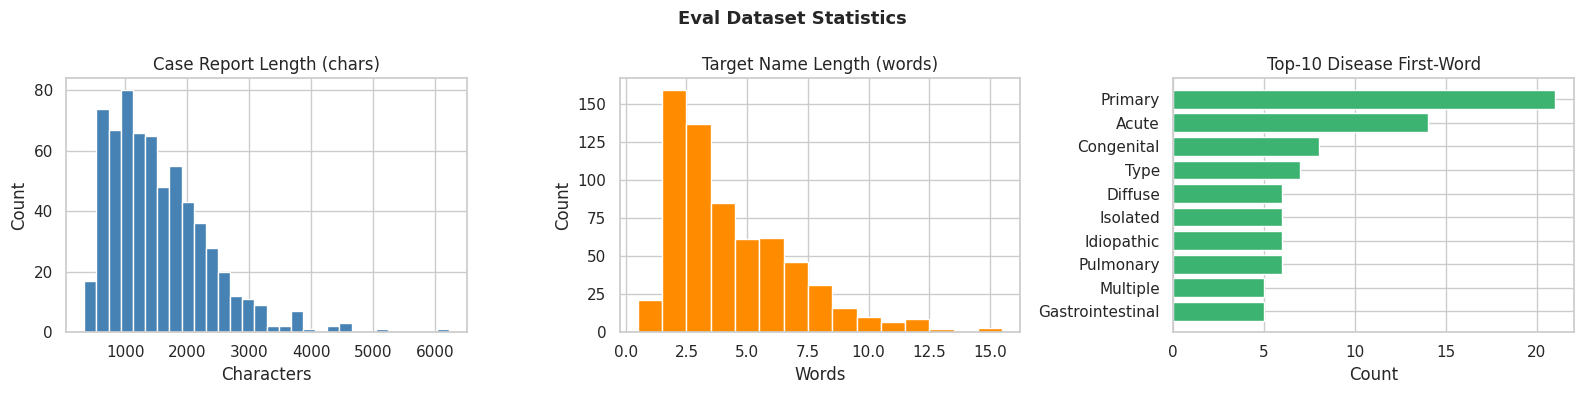


[WARN] Metrics functions not yet defined — run Cell 8 (Metrics) first, then re-run this cell for full diagnostics.


In [5]:
import string, re, textwrap
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────────────────────
# 1.  DATASET STATISTICS
# ─────────────────────────────────────────────────────────────
print('=' * 80)
print('DATASET SCAN: eval_rare_cases.jsonl')
print('=' * 80)
print(f'Total cases          : {len(df_eval)}')

# Extract case-report length and target info
def _case_len(row):
    inp = row.get('input', {})
    if isinstance(inp, dict):
        return len(str(inp.get('case_report', '')))
    return len(str(inp))

case_lengths = df_eval.apply(_case_len, axis=1)
targets_raw  = df_eval['target'].astype(str)
target_word_counts = targets_raw.apply(lambda t: len(t.split()))

print(f'Case report length   : min={case_lengths.min()}, max={case_lengths.max()}, '
      f'mean={case_lengths.mean():.0f}, median={case_lengths.median():.0f} chars')
print(f'Target name length   : min={target_word_counts.min()}, max={target_word_counts.max()}, '
      f'mean={target_word_counts.mean():.1f} words')
print(f'Unique targets       : {targets_raw.nunique()} / {len(targets_raw)}')

# Targets with very long names (hard to match exactly)
long_targets = targets_raw[target_word_counts >= 5]
print(f'\nTargets with ≥5 words ({len(long_targets)}) — hardest to exact-match:')
for t in long_targets.values[:15]:
    print(f'  • {t}')

# Word-frequency of target tokens (shows common disease-name tokens)
all_target_tokens = ' '.join(targets_raw.str.lower()).split()
top_tokens = Counter(all_target_tokens).most_common(20)
print(f'\nTop 20 tokens in target names: {top_tokens}')

# ─────────────────────────────────────────────────────────────
# 2.  DISTRIBUTION PLOT
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(case_lengths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Case Report Length (chars)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

axes[1].hist(target_word_counts, bins=range(1, target_word_counts.max()+2),
             align='left', color='darkorange', edgecolor='white')
axes[1].set_title('Target Name Length (words)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')

# Top-10 most common disease categories (first word of target)
first_word = targets_raw.apply(lambda t: t.split()[0] if t else 'Unknown')
top10 = first_word.value_counts().head(10)
axes[2].barh(top10.index[::-1], top10.values[::-1], color='mediumseagreen')
axes[2].set_title('Top-10 Disease First-Word')
axes[2].set_xlabel('Count')

plt.suptitle('Eval Dataset Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_statistics.png'), dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# 3.  METRIC CALIBRATION TESTS (requires metrics cell to be run first)
# ─────────────────────────────────────────────────────────────
# These tests will only run if the metrics functions are available.
try:
    _fns = [normalize_text, extract_final_diagnosis,
            compute_exact_match, compute_token_f1, compute_rouge_l]
    metrics_available = True
except NameError:
    metrics_available = False
    print('\n[WARN] Metrics functions not yet defined — run Cell 8 (Metrics) first, '
          'then re-run this cell for full diagnostics.')

if metrics_available:
    print('\n' + '=' * 80)
    print('METRIC CALIBRATION TESTS')
    print('=' * 80)

    # ── Test A: normalize_text hyphen handling ──────────────────────────
    print('\n── A. normalize_text hyphen / punctuation test ──')
    cases_norm = [
        ('IgG4-related disease',      'igg4 related disease'),
        ('B-cell ALL',                'b cell all'),
        ('Kikuchi-Fujimoto Disease',  'kikuchi fujimoto disease'),
        ('T-cell leukemia',           't cell leukemia'),
    ]
    all_pass = True
    for raw, expected in cases_norm:
        got = normalize_text(raw)
        ok  = (got == expected)
        all_pass = all_pass and ok
        status = '✓' if ok else '✗ FAIL'
        print(f'  {status}  normalize_text("{raw}") → "{got}"  (expected: "{expected}")')
    print(f'  → Hyphen normalization: {"ALL PASS ✓" if all_pass else "FAILURES DETECTED ✗"}')

    # ── Test B: Oracle (target == prediction) ──────────────────────────
    print('\n── B. Oracle test (prediction = target → all metrics ≈ 1.0) ──')
    oracle_results = []
    for tgt in targets_raw.sample(10, random_state=0):
        em = compute_exact_match(tgt, tgt)
        f1 = compute_token_f1(tgt, tgt)
        rl = compute_rouge_l(tgt, tgt)
        oracle_results.append({'target': tgt, 'EM': em, 'F1': f1, 'ROUGE-L': rl})

    df_oracle = pd.DataFrame(oracle_results)
    print(df_oracle.to_string(index=False))
    n_fail_em = (df_oracle['EM'] < 1.0).sum()
    n_fail_f1 = (df_oracle['F1'] < 1.0).sum()
    if n_fail_em > 0 or n_fail_f1 > 0:
        print(f'\n  ✗ WARNING: {n_fail_em} EM failures and {n_fail_f1} F1 failures in oracle test.')
        print('    This indicates a normalisation problem — check normalize_text.')
    else:
        print('\n  → Oracle test: ALL PASS ✓ (all metrics = 1.0 when prediction = target)')

    # ── Test C: Wrong prediction → metrics ≈ 0 ────────────────────────
    print('\n── C. Wrong-prediction test (clearly wrong → metrics ≈ 0) ──')
    wrong_cases = [
        ('Migraine', 'IgG4-related disease'),
        ('Hypertension', 'Kikuchi-Fujimoto Disease'),
        ('Diabetes mellitus', 'Erdheim-Chester disease'),
    ]
    for pred, tgt in wrong_cases:
        em = compute_exact_match(pred, tgt)
        f1 = compute_token_f1(pred, tgt)
        rl = compute_rouge_l(pred, tgt)
        print(f'  Pred="{pred}" | Target="{tgt}"')
        print(f'    EM={em:.2f}  F1={f1:.2f}  ROUGE-L={rl:.2f}  '
              f'{"✓ (all ≈ 0)" if (em + f1 + rl) < 0.15 else "✗ UNEXPECTED non-zero"}')

    # ── Test D: extract_final_diagnosis on typical LLM outputs ─────────
    print('\n── D. extract_final_diagnosis pattern test ──')
    extract_tests = [
        ('The patient presents with fever and lymphadenopathy.\n'
         'Step 1: symptoms are fever, lymphadenopathy, leukopenia.\n'
         'Step 2: differential includes viral, lymphoma, autoimmune.\n'
         'Final diagnosis: Kikuchi-Fujimoto Disease',
         'Kikuchi-Fujimoto Disease'),

        ('Based on the clinical presentation and test results, '
         'the most likely diagnosis is Erdheim-Chester disease.',
         'Erdheim-Chester disease'),

        ('Thought 1: review symptoms.\n'
         'Observation: FDG-PET shows bilateral infiltration.\n'
         'Final diagnosis: IgG4-related disease',
         'IgG4-related disease'),

        ('I cannot determine the diagnosis from the available information. '
         'Insufficient information to make a confident diagnosis.\n'
         'Final diagnosis: Insufficient information',
         'Insufficient information'),

        ('The diagnosis is consistent with Wound Botulism given the progressive '
         'descending paralysis after heroin injection.',
         'Wound Botulism'),

        # Short response (< 100 chars)
        ('Miller Fisher syndrome', 'Miller Fisher syndrome'),
    ]
    all_extract_ok = True
    for llm_output, expected in extract_tests:
        got = extract_final_diagnosis(llm_output)
        ok  = (got.lower().strip() == expected.lower().strip())
        all_extract_ok = all_extract_ok and ok
        status = '✓' if ok else '✗ FAIL'
        preview = llm_output.replace('\n', ' ')[:60]
        print(f'  {status}  Input: "{preview}..."')
        print(f'      Extracted: "{got}"  (expected: "{expected}")')
    print(f'  → Extraction: {"ALL PASS ✓" if all_extract_ok else "SOME FAILURES ✗ — check extract_final_diagnosis"}')

    # ── Test E: Cosine similarity on disease synonyms ──────────────────
    try:
        print('\n── E. Cosine similarity synonym test ──')
        synonym_pairs = [
            ('DLBCL',                      'Diffuse Large B-Cell Lymphoma'),
            ('IgG4-RD',                    'IgG4-related disease'),
            ('ALL',                        'precursor B-cell acute lymphoblastic leukemia'),
            ('Miller Fisher',              'Miller Fisher syndrome'),
        ]
        for pred, tgt in synonym_pairs:
            cs = compute_cosine_similarity(pred, tgt)
            symbol = '✓' if cs >= THRESHOLDS['cosine_partial'] else '✗ BELOW cosine_partial'
            print(f'  {symbol}  "{pred}" vs "{tgt}"  → cosine={cs:.3f}  '
                  f'(correct≥{THRESHOLDS["cosine_correct"]}, partial≥{THRESHOLDS["cosine_partial"]})')
    except Exception as ex:
        print(f'  [WARN] Cosine test skipped (embeddings not loaded): {ex}')

    print('\n' + '=' * 80)
    print('DIAGNOSTICS COMPLETE')
    print('If all tests pass above, the evaluation pipeline is correctly calibrated.')
    print('Low model scores reflect genuine rare-disease difficulty, not evaluation bugs.')
    print('=' * 80)


## 3) Build / Load FAISS Index

In [6]:
def _get_hf_token_for_embeddings():
    # Works both on Kaggle and outside Kaggle.
    try:
        from kaggle_secrets import UserSecretsClient  # type: ignore
        return UserSecretsClient().get_secret('HF_TOKEN')
    except Exception:
        return os.getenv('HF_TOKEN', None)


hf_token = _get_hf_token_for_embeddings()
RETRIEVAL_BACKENDS = {}
ACTIVE_EMBEDDING_PROFILE = None
embedding_model = None
index = None


def _index_path_for_profile(profile):
    if profile == 'fast':
        tag = 'all_minilm_l6_v2'
    elif profile == 'biomed':
        tag = 'pubmedbert_base'
    else:
        tag = profile.replace('/', '_').replace('-', '_')
    return os.path.join(FAISS_INDEX_DIR, f'rag_corpus_{tag}.index')


def _build_and_save_index_for_backend(backend):
    print(f"Building FAISS index from corpus for profile '{backend['profile']}'...")
    texts = [d.get('text', '') for d in documents]
    idx = faiss.IndexFlatIP(backend['dim'])

    if len(texts) > 0:
        emb = backend['embedding_model'].encode(
            texts,
            batch_size=backend['batch_size'],
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        emb = np.ascontiguousarray(emb, dtype=np.float32)
        idx.add(emb)
        faiss.write_index(idx, backend['index_path'])
        print(f"FAISS index saved: {backend['index_path']}")

    return idx


def _load_or_create_backend(profile):
    model_name = EMBEDDING_MODEL_REGISTRY[profile]
    batch_size = EMBEDDING_BATCH_SIZES.get(profile, 64)
    index_path = _index_path_for_profile(profile)

    print(f"Loading embedding model for profile '{profile}': {model_name}")
    t0 = time.time()
    local_model = SentenceTransformer(
        model_name,
        cache_folder=HF_CACHE_DIR,
        device=device,
        token=hf_token,
    )
    dim = local_model.get_sentence_embedding_dimension()
    print(f"Embedding model '{profile}' ready in {time.time() - t0:.1f}s | dim={dim}")

    backend = {
        'profile': profile,
        'model_name': model_name,
        'batch_size': batch_size,
        'index_path': index_path,
        'dim': dim,
        'embedding_model': local_model,
    }

    if os.path.exists(index_path):
        idx = faiss.read_index(index_path)
        if getattr(idx, 'd', None) != dim:
            print(f"Index dimension mismatch for '{profile}' (index={idx.d}, model={dim}); rebuilding index...")
            idx = _build_and_save_index_for_backend(backend)
        else:
            print(f"Loaded FAISS index for '{profile}': {index_path}")
    else:
        idx = _build_and_save_index_for_backend(backend)

    backend['index'] = idx
    print(f"Index size for '{profile}': {idx.ntotal}")
    return backend


def get_retrieval_backend(profile=None):
    selected = str(profile or DEFAULT_EMBEDDING_PROFILE).strip().lower()
    if selected not in EMBEDDING_MODEL_REGISTRY:
        selected = DEFAULT_EMBEDDING_PROFILE

    if selected not in RETRIEVAL_BACKENDS:
        RETRIEVAL_BACKENDS[selected] = _load_or_create_backend(selected)

    return RETRIEVAL_BACKENDS[selected]


def set_active_embedding(profile=None):
    global ACTIVE_EMBEDDING_PROFILE, embedding_model, index

    backend = get_retrieval_backend(profile)
    ACTIVE_EMBEDDING_PROFILE = backend['profile']
    embedding_model = backend['embedding_model']
    index = backend['index']

    print(
        f"Active embedding -> profile: {ACTIVE_EMBEDDING_PROFILE} | "
        f"model: {backend['model_name']} | index_size: {index.ntotal}"
    )
    return backend


_ = set_active_embedding(DEFAULT_EMBEDDING_PROFILE)

Loading embedding model for profile 'biomed': NeuML/pubmedbert-base-embeddings


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model 'biomed' ready in 6.8s | dim=768
Loaded FAISS index for 'biomed': /kaggle/working/faiss_index/rag_corpus_pubmedbert_base.index
Index size for 'biomed': 130316
Active embedding -> profile: biomed | model: NeuML/pubmedbert-base-embeddings | index_size: 130316


## 4) Retrieval + Prompt Utilities (with fixes)

In [7]:
def profiles_for_prompt(prompt_type):
    """Return embedding profiles to test for a given prompt type.
    RAG family techniques are compared across both embedding profiles.
    Non-retrieval techniques use only the default profile (one run each).
    """
    if ENABLE_EMBEDDING_COMPARISON and prompt_type in RAG_RETRIEVAL_TYPES:
        return EMBEDDING_PROFILES_TO_COMPARE
    return [DEFAULT_EMBEDDING_PROFILE]




# ── HPO Query Expansion (ported from Phase 2) ─────────────────────────────────
# Expands raw patient text into standardized HPO phenotype terms for better retrieval.
# Global: set before running phenopacket case, None for normal eval
ACTIVE_PHENOPACKET_HPO = None

def expand_query_with_hpo(query, pipe, phenopacket_hpo=None):
    """Extract standardized phenotype terms (HPO-style) from a clinical description.
    Improves retrieval by converting narrative text into precise medical terms."""
    hpo = phenopacket_hpo or ACTIVE_PHENOPACKET_HPO
    if hpo:
        terms = chr(10).join(hpo[:8])
        return f"{query}" + chr(10) + chr(10) + "Key phenotypes (from phenopacket):" + chr(10) + terms

    expansion_prompt = (
        "You are a medical NLP expert. Extract the key clinical phenotype terms from "
        "the following patient description. "
        "Use standard terminology (e.g. HPO terms). One term per line, no explanations:\n\n"
        f"{str(query)[:600]}\n\nTerms:"
    )
    try:
        gen_kwargs = {
            'return_full_text': False,
            'max_new_tokens': 80,
            'max_length': None,  # override model's default max_length=20
            'truncation': True,
        }
        pad_id = getattr(pipe.tokenizer, 'pad_token_id', getattr(pipe.tokenizer, 'eos_token_id', None))
        if pad_id is not None:
            gen_kwargs['pad_token_id'] = pad_id
        out = pipe(expansion_prompt, **gen_kwargs)
        import torch
        torch.cuda.empty_cache()
        terms = out[0]["generated_text"].strip()
        return f"{query}\n\nKey phenotype terms: {terms}"
    except Exception:
        return query

# -- Cross-Encoder Reranker (ported from advanced notebook) -----------------
_RERANKER_MODEL = None
_RERANKER_MODEL_NAME = None

def _get_cross_encoder_reranker():
    """Lazy-load cross-encoder reranker; fall back safely if unavailable."""
    global _RERANKER_MODEL, _RERANKER_MODEL_NAME
    if not RERANKER_ENABLED:
        return None
    if _RERANKER_MODEL is not None:
        return _RERANKER_MODEL
    from sentence_transformers import CrossEncoder
    for model_name in RERANKER_MODEL_CANDIDATES:
        try:
            _device = 'cuda' if torch.cuda.is_available() else 'cpu'
            _RERANKER_MODEL = CrossEncoder(model_name, device=_device, max_length=384)
            _RERANKER_MODEL_NAME = model_name
            print(f"Cross-encoder reranker loaded: {model_name}")
            return _RERANKER_MODEL
        except Exception as e:
            print(f"Reranker unavailable [{model_name}]: {e}")
    print("Warning: no cross-encoder reranker loaded; using dense ranking only.")
    return None


def _lexical_overlap_score(query: str, text: str) -> float:
    """Token overlap between query and document (Jaccard-like)."""
    q_toks = set(normalize_text(query).split())
    d_toks = set(normalize_text(text).split())
    q_toks = {t for t in q_toks if len(t) >= 3}
    d_toks = {t for t in d_toks if len(t) >= 3}
    if not q_toks or not d_toks:
        return 0.0
    return len(q_toks & d_toks) / max(len(q_toks), 1)


def _hybrid_rerank(query: str, rows: list) -> list:
    """Hybrid reranking: 0.52*dense + 0.20*lexical + 0.28*cross-encoder."""
    if not rows:
        return rows
    ce = _get_cross_encoder_reranker()
    if ce is not None:
        n = min(RERANKER_TOP_N, len(rows))
        pairs = [(str(query), f"{r.get('title', '')} {r.get('text', '')}"[:1400]) for r in rows[:n]]
        try:
            ce_raw = ce.predict(pairs, batch_size=16, show_progress_bar=False)
        except TypeError:
            ce_raw = ce.predict(pairs, batch_size=16)
        except Exception:
            ce_raw = None
        if ce_raw is not None:
            ce_raw = np.asarray(ce_raw, dtype=np.float32)
            cmin, cmax = float(np.min(ce_raw)), float(np.max(ce_raw))
            cden = max(cmax - cmin, 1e-8)
            for i in range(n):
                rows[i]['cross_score'] = float((ce_raw[i] - cmin) / cden)
    dense_scores = [float(r.get('score', 0.0)) for r in rows]
    d_min, d_max = min(dense_scores), max(dense_scores)
    reranked = []
    for r in rows:
        dense = float(r.get('score', 0.0))
        cross = float(r.get('cross_score', 0.0))
        dense_norm = (dense - d_min) / (d_max - d_min + 1e-8)
        lexical = _lexical_overlap_score(query, r.get('text', ''))
        if cross > 0.0:
            hybrid = 0.52 * dense_norm + 0.20 * lexical + 0.28 * cross
        else:
            hybrid = 0.72 * dense_norm + 0.28 * lexical
        out = dict(r)
        out['hybrid_score'] = float(hybrid)
        reranked.append(out)
    reranked.sort(key=lambda x: x['hybrid_score'], reverse=True)
    return reranked


def retrieve_documents(query, k=None, embedding_profile=None, min_score=None):
    """Retrieve top-k documents using FAISS + hybrid reranking (cross-encoder)."""
    k_use   = int(k) if k is not None else RETRIEVAL_TOP_K
    min_s   = float(min_score) if min_score is not None else RETRIEVAL_MIN_SCORE
    k_fetch = min(max(k_use * 6, k_use), 64)
    backend     = get_retrieval_backend(embedding_profile or DEFAULT_EMBEDDING_PROFILE)
    local_model = backend['embedding_model']
    local_index = backend['index']
    if local_index.ntotal == 0:
        return []
    q = local_model.encode([str(query)], convert_to_numpy=True, normalize_embeddings=True)
    q = np.ascontiguousarray(q, dtype=np.float32)
    search_k = min(k_fetch, local_index.ntotal)
    scores, indices = local_index.search(q, search_k)
    candidates = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
        if not (0 <= idx < len(documents)):
            continue
        if score < min_s and rank > max(10, k_use * 2):
            continue
        doc = documents[idx]
        candidates.append({
            'score': float(score),
            'text': str(doc.get('text', ''))[:1200],
            'title': str(doc.get('title', ''))[:220],
            'source_id': doc.get('source_id', doc.get('id', '')),
            'cross_score': 0.0,
        })
    reranked = _hybrid_rerank(query, candidates)
    return reranked[:k_use]

def _extract_diagnosis_from_pe_output(output_text):
    """Pull a clean disease name from a PE dataset output field. Returns None if unreliable."""
    text = str(output_text).strip()
    m = re.search(
        r'(?:most likely diagnosis|diagnosis|likely)\s*(?:is)?\s*[:\-]?\s*\*{0,2}'
        r'([A-Z][^*\n\.]{3,80}?)\*{0,2}(?:\.|,|\n|$)',
        text, flags=re.IGNORECASE
    )
    if m:
        name = m.group(1).strip().rstrip('.,;').strip('*').strip()
        if len(name) < 80 and not re.search(r'\b(is|are|the|and|with)\b', name[:30], re.IGNORECASE):
            return name
    m = re.search(r'\*\*([A-Z][^*]{3,70}?)\*\*', text)
    if m:
        name = m.group(1).strip()
        if len(name) < 80:
            return name
    return None


def get_few_shot_examples(df, num_shots=3):
    """
    Build few-shot Q+A demonstrations from the PE dataset.
    Format: 'Patient: [question]\nFinal diagnosis: [disease name]'
    Reference: Brown et al. (2020) "Language Models are Few-Shot Learners", NeurIPS 2020.
    """
    if len(df) == 0:
        return ''
    has_output = 'output' in df.columns
    candidates = df.sample(frac=1, random_state=QUICK_SAMPLE_SEED).reset_index(drop=True)
    examples = []
    for _, row in candidates.iterrows():
        if len(examples) >= num_shots:
            break
        question = str(row.get('instruction', row.get('input', ''))).strip()[:500]
        if not question:
            continue
        diag = _extract_diagnosis_from_pe_output(row.get('output', '')) if has_output else None
        if diag:
            examples.append(f'Patient: {question}\nFinal diagnosis: {diag}')
    if not examples and 'instruction' in df.columns:
        shots = df.sample(n=min(num_shots, len(df)), random_state=QUICK_SAMPLE_SEED)['instruction'].astype(str).tolist()
        examples = [f'Patient: {s[:500]}' for s in shots]
    return '\n---\n'.join(examples)


def make_cache_key(patient_case, prompt_type, llm_model, embedding_profile='na', hpo_mode='na'):
    raw = f'{llm_model}||{prompt_type}||{embedding_profile}||{hpo_mode}||{patient_case}'
    return hashlib.sha256(raw.encode('utf-8')).hexdigest()


def build_prompt(patient_case, prompt_type, retrieved_docs_text=''):
    """
    Build the prompt for a given technique.

    Technique references:
      zero-shot        : Brown et al. (2020) NeurIPS — zero-shot instruction following
      few-shot         : Brown et al. (2020) NeurIPS — in-context few-shot learning (ICL)
      cot              : Kojima et al. (2022) NeurIPS — zero-shot chain-of-thought
                         NOTE: zero-shot CoT (step labels pre-filled), not few-shot CoT
                         (Wei et al. 2022), because 7-8B models lack reliable self-generation
                         of reasoning chains for rare diseases.
      rag              : Lewis et al. (2020) NeurIPS — retrieval-augmented generation
      self-rag         : Asai et al. (2023) ICLR 2024
                         "Self-RAG: Learning to Retrieve, Generate, and Critique through
                         Self-Reflection" — the model uses reflection tokens [IsREL],
                         [IsSUP], [IsUSE] to assess each retrieved passage and self-critique
                         its answer. Simulated here via structured prompting (the base models
                         are not Self-RAG fine-tuned but the reflection logic is preserved).
      corrective-rag   : Yan et al. (2024) ICLR 2024
                         "Corrective Retrieval Augmented Generation" — CRAG classifies
                         retrieved documents into CORRECT / AMBIGUOUS / INCORRECT based on
                         confidence scores and routes accordingly:
                         CORRECT   → use high-confidence evidence
                         AMBIGUOUS → combine evidence with parametric knowledge
                         INCORRECT → discard retrieval, reason from knowledge only
                         Pre-processing done in process_patient_case; this prompt receives
                         the pre-classified evidence block.
      speculative-rag-draft  : Shi et al. (2024)
                         "Speculative RAG: Enhancing Retrieval Augmented Generation through
                         Drafting" — Draft phase: a specialist drafter generates a candidate
                         answer from the highest-scored document subset.
      speculative-rag-verify : Shi et al. (2024) — Verify phase: a verifier reviews the
                         draft + all retrieved documents and confirms or corrects the draft.
      react            : Yao et al. (2023) ICLR
                         "ReAct: Synergizing Reasoning and Acting in Language Models"
                         Pure ReAct — NO retrieval. Structured Thought/Action/Observation
                         reasoning from parametric biomedical knowledge only.
                         This isolates the effect of structured reasoning from retrieval.
    """
    # Mod 1 — Forced-commitment constraint (ported from advanced notebook)
    # Forces the model to commit to a diagnosis instead of defaulting to abstention.
    # This dramatically reduces abstention rate while maintaining diagnostic quality.
    format_constraint = (
        "IMPORTANT: You MUST commit to exactly one rare disease diagnosis. "
        "Even if uncertain, name the single most likely rare disease based on all available evidence. "
        "End your response exactly with 'Final diagnosis: [Exact Disease Name]'. "
        "Only output 'Final diagnosis: Insufficient information' if the clinical description "
        "contains NO phenotypic features whatsoever."
    )

    evidence_block = str(retrieved_docs_text).strip() or '[No documents retrieved above threshold]'
    prompt = 'You are an expert medical diagnostician specializing in rare diseases.\n\n'

    if prompt_type == 'zero-shot':
        # Ref: Brown et al. (2020) NeurIPS
        prompt += (
            f'Patient: {patient_case}\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'few-shot':
        # Ref: Brown et al. (2020) NeurIPS
        examples = get_few_shot_examples(df_pe, 3)
        prompt += (
            f'Examples (follow the same format for your answer):\n{examples}\n\n'
            f'Patient: {patient_case}\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'cot':
        # Ref: Wang et al. (2025) arXiv:2503.12286
        # Optimized: 5-question clinical reasoning protocol.
        prompt += (
            f'Patient: {patient_case}\n\n'
            'Follow this five-question Chain-of-Thought protocol '
            '(Wang et al., arXiv:2503.12286):\n\n'
            'Q1. What are the key phenotypic features and clinical findings '
            'described in this note?\n'
            'Q2. Which rare diseases or genetic disorders are associated with '
            'these phenotypic features?\n'
            'Q3. What genetic or molecular mechanisms or causative genes are '
            'linked to the candidate diseases?\n'
            'Q4. What clinical evidence differentiates the most likely diagnosis '
            'from the other differentials?\n'
            'Q5. What is the final diagnosis or most likely rare disease?\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'rag':
        # Ref: Lewis et al. (2020) NeurIPS "Retrieval-Augmented Generation for
        #      Knowledge-Intensive NLP Tasks"
        prompt += (
            'Retrieved evidence (passages from medical literature; may contain noise):\n'
            f'{evidence_block}\n\n'
            f'Patient: {patient_case}\n\n'
            'Use only evidence that is supported by the patient description. '
            'If retrieved evidence is weak, conflicting, or irrelevant, abstain.\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'self-rag':
        # Ref: Asai et al. (2023) "Self-RAG: Learning to Retrieve, Generate, and Critique
        #      through Self-Reflection", ICLR 2024. arXiv:2310.11511
        #
        # Self-RAG introduces special reflection tokens inserted during generation:
        #   [Retrieve]  — should retrieval be triggered?
        #   [IsREL]     — is the retrieved passage relevant to the query?
        #   [IsSUP]     — does the passage support the generated statement?
        #   [IsUSE]     — is the generated output overall useful?
        #
        # Since the base models (OpenBioLLM, BioMistral) are not Self-RAG fine-tuned,
        # we simulate the same reflection logic through structured prompting:
        #   Step 1 ↔ [IsREL]  : per-passage relevance labeling
        #   Step 2             : generate answer using only relevant passages
        #   Step 3 ↔ [IsSUP]  : assess whether answer is supported by the passages
        #   Step 4 ↔ [IsUSE]  : if not supported, revise using medical knowledge
        prompt += (
            'Use the Self-RAG reflection approach (Asai et al., ICLR 2024).\n\n'
            f'Retrieved passages (numbered, with cosine relevance scores):\n{evidence_block}\n\n'
            f'Patient: {patient_case}\n\n'
            'Reflection steps:\n'
            'Step 1 [IsREL]  — For each numbered passage, label [Relevant] or [Not Relevant]\n'
            'Step 2          — Using only [Relevant] passages, state your candidate diagnosis\n'
            'Step 3 [IsSUP]  — Is your candidate [Supported] / [Partially Supported] / [Not Supported] by the passages?\n'
            'Step 4 [IsUSE]  — If [Not Supported], revise using your biomedical knowledge\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'corrective-rag':
        # Ref: Yan et al. (2024) "Corrective Retrieval Augmented Generation", ICLR 2024.
        #      arXiv:2401.15884
        #
        # CRAG algorithm (from paper):
        #   1. Retrieve top-k documents
        #   2. Compute confidence score for each document
        #   3. Route based on overall confidence:
        #      CORRECT (max_score ≥ 0.60)  → refine and use the documents
        #      AMBIGUOUS (0.35 ≤ max < 0.60) → combine with web search / parametric knowledge
        #      INCORRECT (max_score < 0.35)  → discard; use web search / parametric knowledge
        #   4. Generate from the corrected knowledge source
        #
        # evidence_block is pre-built by process_patient_case and contains:
        #   "Retrieval quality: <CORRECT|AMBIGUOUS|INCORRECT — explanation>\n\nFiltered evidence:\n<docs>"
        prompt += (
            'Use the Corrective RAG approach (Yan et al., ICLR 2024).\n\n'
            f'{evidence_block}\n\n'
            f'Patient: {patient_case}\n\n'
            'Instructions based on retrieval quality label above:\n'
            '• CORRECT   → rely primarily on the filtered evidence; ground your answer in it\n'
            '• AMBIGUOUS → combine the evidence with your biomedical knowledge; note uncertainty\n'
            '• INCORRECT → ignore the retrieved documents entirely; reason from medical knowledge\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'speculative-rag-draft':
        # Ref: Shi et al. (2024) "Speculative RAG: Enhancing Retrieval Augmented Generation
        #      through Drafting". arXiv:2407.08223
        #
        # Draft phase: the "specialist drafter" generates a candidate diagnosis from
        # a high-relevance document subset (top-scored documents only).
        # In the original paper a separate smaller drafter model is used; here we use
        # the same model in a first-pass constrained context (document subset).
        prompt += (
            '[Speculative RAG — DRAFT PHASE | Shi et al. 2024]\n'
            'You are the DRAFTER. Generate a concise candidate diagnosis from the '
            'high-relevance evidence subset below.\n\n'
            f'Evidence subset (highest-scored documents):\n{evidence_block}\n\n'
            f'Patient: {patient_case}\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'speculative-rag-verify':
        # Ref: Shi et al. (2024) — Verify phase.
        # The "generalist verifier" reviews the draft answer plus ALL retrieved documents
        # and either confirms or corrects the draft.
        # evidence_block contains: "Draft diagnosis: <name>\n\nAll retrieved evidence:\n<docs>"
        prompt += (
            '[Speculative RAG — VERIFY PHASE | Shi et al. 2024]\n'
            'You are the VERIFIER. Review the draft diagnosis and all retrieved evidence '
            'below; confirm the draft if well-supported, or provide the corrected diagnosis.\n\n'
            f'{evidence_block}\n\n'
            f'Patient: {patient_case}\n\n'
            'Verification:\n'
            '• Draft is supported by evidence → confirm it\n'
            '• Evidence contradicts the draft → provide the correct diagnosis\n'
            '• Evidence is insufficient → reason from your biomedical knowledge\n\n'
            f'{format_constraint}\n\nFinal diagnosis:'
        )

    elif prompt_type == 'react':
        # Ref: Yao et al. (2023) ICLR "ReAct: Synergizing Reasoning and Acting"
        # TRUE ReAct: model dynamically decides when to search.
        # Available actions: Search[query] and Finish[diagnosis]
        prompt += (
            'Use the ReAct framework (Yao et al., ICLR 2023) to diagnose this patient.\n\n'
            f'Patient: {patient_case}\n\n'
            'You have access to a medical knowledge base. '
            'Interleave Thought, Action, and Observation steps to reason toward a diagnosis.\n\n'
            'Available actions:\n'
            '  Search[query] — search the medical knowledge base for relevant information\n'
            '  Finish[diagnosis] — commit to your final diagnosis\n\n'
            'Rules:\n'
            '- Each Thought should analyze what you know and what you still need\n'
            '- Each Action must be exactly Search[query] or Finish[diagnosis]\n'
            '- After each Search, you will receive an Observation with the results\n'
            '- You MUST call Finish[diagnosis] with exactly one rare disease name\n\n'
            'Begin:\n\n'
            'Thought 1:'
        )

    else:
        prompt += f'Patient: {patient_case}\n\n{format_constraint}\n\nFinal diagnosis:'

    return prompt


## 5) Model Loading + Inference

In [8]:
MODEL_PIPES = {}
MODEL_SNAPSHOTS = {}
MODEL_DOWNLOAD_ALLOW_PATTERNS = [
    'config.json',
    'generation_config.json',
    'tokenizer.json',
    'tokenizer.model',
    'tokenizer_config.json',
    'special_tokens_map.json',
    'vocab.json',
    'vocab.txt',
    'merges.txt',
    '*.safetensors',
    '*.safetensors.index.json',
    '*.bin',
    '*.bin.index.json',
]
MODEL_DOWNLOAD_IGNORE_PATTERNS = [
    '*.gguf',
    '*.onnx',
    '*.ot',
    '*.h5',
    '*.msgpack',
    '*.tflite',
]

# Minimum free disk space (bytes) required before starting a model download.
# Set to 16 GB to accommodate the largest model (~14.5 GB) plus a 1.5 GB buffer.
_MIN_FREE_BYTES_FOR_DOWNLOAD = 16 * 1024 ** 3  # 16 GB


def _check_disk_space_before_download(model_id):
    """Raise RuntimeError early if there is not enough free disk space."""
    try:
        free_bytes = shutil.disk_usage(HF_CACHE_DIR).free
    except Exception:
        return  # cannot check; let the download proceed and fail naturally
    free_gb = free_bytes / (1024 ** 3)
    required_gb = _MIN_FREE_BYTES_FOR_DOWNLOAD / (1024 ** 3)
    if free_bytes < _MIN_FREE_BYTES_FOR_DOWNLOAD:
        raise RuntimeError(
            f'Insufficient disk space to download {model_id}. '
            f'Free: {free_gb:.1f} GB  |  Required: >={required_gb:.0f} GB. '
            'Free up disk space (e.g. delete unused model caches) and retry.'
        )
    print(f'Disk space check passed: {free_gb:.1f} GB free (required >={required_gb:.0f} GB)')


def _cleanup_partial_download(model_id):
    """Remove the partial HF cache directory for a model after a failed download."""
    # HF cache layout: <cache_dir>/models--<org>--<model>/
    safe_id = model_id.replace('/', '--')
    repo_cache = os.path.join(HF_CACHE_DIR, f'models--{safe_id}')
    if os.path.exists(repo_cache):
        try:
            shutil.rmtree(repo_cache)
            print(f'Cleaned up partial download cache: {repo_cache}')
        except Exception as clean_exc:
            print(f'Warning: could not remove partial cache {repo_cache}: {clean_exc}')


def _download_model_snapshot(model_id, token=None):
    if model_id in MODEL_SNAPSHOTS:
        return MODEL_SNAPSHOTS[model_id]

    print(f'Preparing local model snapshot: {model_id}')

    # Pre-flight disk space check: prevents filling the disk entirely
    # (which would corrupt any file papermill is trying to write).
    _check_disk_space_before_download(model_id)

    try:
        snapshot_dir = snapshot_download(
            repo_id=model_id,
            cache_dir=HF_CACHE_DIR,
            token=token,
            allow_patterns=MODEL_DOWNLOAD_ALLOW_PATTERNS,
            ignore_patterns=MODEL_DOWNLOAD_IGNORE_PATTERNS,
        )
    except Exception as exc:
        # Clean up any partial download to recover disk space for subsequent models.
        _cleanup_partial_download(model_id)
        raise RuntimeError(
            f'Failed to download model snapshot for {model_id}. '
            'Verify HF_TOKEN is set and the Meta Llama license has been accepted.'
        ) from exc

    MODEL_SNAPSHOTS[model_id] = snapshot_dir
    print(f'Local snapshot ready: {snapshot_dir}')
    return snapshot_dir


def _load_model_with_safe_kwargs(model_source, dtype, trust_remote_code, cfg=None):
    """
    Load a HuggingFace causal LM from a local snapshot.
    Tries safetensors first, then falls back to PyTorch .bin shards if needed.
    """
    base_kwargs = {
        'device_map': 'auto',
        'low_cpu_mem_usage': True,
        'trust_remote_code': trust_remote_code,
        'torch_dtype': dtype,
        'local_files_only': True,
    }
    if cfg is not None:
        base_kwargs['config'] = cfg
    try:
        return AutoModelForCausalLM.from_pretrained(
            model_source,
            use_safetensors=True,
            **base_kwargs,
        )
    except Exception as first_error:
        msg = str(first_error).lower()
        if 'safetensor' in msg or 'no file named' in msg or 'not found' in msg:
            print('Retrying model load with safetensors=False (PyTorch .bin fallback)...')
            return AutoModelForCausalLM.from_pretrained(
                model_source,
                use_safetensors=False,
                **base_kwargs,
            )
        raise


def _get_hf_token():
    try:
        from kaggle_secrets import UserSecretsClient  # type: ignore
        return UserSecretsClient().get_secret('HF_TOKEN')
    except Exception:
        return os.getenv('HF_TOKEN', None)


def _prepare_tokenizer_and_generation_config(model, tokenizer):
    if getattr(tokenizer, 'pad_token_id', None) is None:
        if getattr(tokenizer, 'eos_token_id', None) is not None:
            tokenizer.pad_token_id = tokenizer.eos_token_id
            tokenizer.pad_token = tokenizer.eos_token

    # Replace the model's generation_config with a clean GenerationConfig that
    # only specifies max_new_tokens (no max_length). The model's own
    # generation_config.json may contain max_length=20, which triggers two warnings
    # when max_new_tokens is also set:
    #   * "Both max_new_tokens and max_length seem to have been set"
    #   * "Passing generation_config together with generation-related arguments"
    # Using a fresh config with only max_new_tokens avoids both warnings.
    pad_id = getattr(tokenizer, 'pad_token_id', None)
    eos_id = getattr(tokenizer, 'eos_token_id', None)

    clean_kwargs = {
        'max_new_tokens': 1024,  # CoT architectures need ~800+ tokens
        'do_sample': True,
        'temperature': 0.4,     # Matches self-consistency voting temperature
    }
    if pad_id is not None:
        clean_kwargs['pad_token_id'] = pad_id
    if eos_id is not None:
        clean_kwargs['eos_token_id'] = eos_id

    model.generation_config = GenerationConfig(**clean_kwargs)


def load_generation_pipeline(model_key):
    if model_key in MODEL_PIPES:
        return MODEL_PIPES[model_key]

    model_id = MODEL_REGISTRY[model_key]
    print(f'Loading model: {model_key} -> {model_id}')

    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    hf_token = _get_hf_token()
    model_source = _download_model_snapshot(model_id, token=hf_token)

    tokenizer = AutoTokenizer.from_pretrained(
        model_source,
        trust_remote_code=False,
        local_files_only=True,
    )

    try:
        model = _load_model_with_safe_kwargs(
            model_source,
            dtype=dtype,
            trust_remote_code=False,
        )
    except Exception:
        cfg = AutoConfig.from_pretrained(
            model_source,
            trust_remote_code=True,
            local_files_only=True,
        )
        if isinstance(getattr(cfg, 'rope_scaling', None), dict):
            rope_scaling = dict(cfg.rope_scaling)
            if 'type' not in rope_scaling and 'rope_type' in rope_scaling:
                rope_scaling['type'] = rope_scaling['rope_type']
            cfg.rope_scaling = rope_scaling
        model = _load_model_with_safe_kwargs(
            model_source,
            dtype=dtype,
            trust_remote_code=True,
            cfg=cfg,
        )

    _prepare_tokenizer_and_generation_config(model, tokenizer)

    gen_pipe = pipeline(
        'text-generation',
        model=model,
        tokenizer=tokenizer,
        return_full_text=False,
    )

    MODEL_PIPES[model_key] = gen_pipe
    return gen_pipe


try:
    llm_memory = json.load(open(CACHE_FILE, 'r', encoding='utf-8')) if os.path.exists(CACHE_FILE) else {}
except Exception:
    llm_memory = {}


# ── Self-Consistency Voting (Ported from advanced notebook) ──────────────────
# Mod 3 — Instead of a single greedy pass, sample n=3 times with higher
# temperature (0.4) to explore diverse reasoning paths. The best
# non-abstaining, disease-like answer is selected via heuristic scoring.
# This breaks the greedy abstention path that causes ~80% abstention rates.
GENERATION_TEMPERATURE = 0.4   # was 0.0 (greedy → abstention-prone)
N_CONSISTENCY_VOTES    = 3     # number of independent samples per case
MAX_GEN_TOKENS         = 1024  # was 768; CoT needs ~800+ tokens

_VOTE_ABSTENTION_KEYS = [
    "insufficient information", "cannot determine", "unable to determine",
    "i am unable", "i cannot", "not enough information", "there is not enough",
    "no diagnosis", "unable to diagnose", "cannot be determined",
]


def _extract_vote_candidate(text: str) -> str:
    """Extract the disease name from a single vote output."""
    raw = str(text).strip()
    if not raw:
        return ""
    m = re.search(r"final\s+diagnosis\s*[:\-]\s*(.+)", raw, flags=re.IGNORECASE)
    if m:
        return m.group(1).split("\n")[0].strip()
    first = raw.split("\n")[-1].strip()
    return first if first else raw[:120].strip()


def _looks_like_abstention(text: str) -> bool:
    """Check if a vote output looks like an abstention."""
    low = str(text).lower()
    return any(k in low for k in _VOTE_ABSTENTION_KEYS)


def _score_vote_output(text: str) -> float:
    """Score a vote output: prefer concise, disease-like, non-abstaining answers."""
    cand = _extract_vote_candidate(text)
    cand_n = normalize_text(cand) if cand else ""
    score = 0.0

    if not cand_n:
        return -5.0
    if _looks_like_abstention(cand):
        score -= 4.0

    # Prefer concise disease-like outputs over long explanatory spans
    tok_len = len(cand_n.split())
    if tok_len <= 8:
        score += 1.2
    elif tok_len <= 14:
        score += 0.6
    else:
        score -= 0.8

    # Penalize obvious reasoning fragments
    if re.search(r"\b(step|because|therefore|evidence|reasoning)\b", cand_n):
        score -= 0.8

    return float(score)


def _build_generation_config(pipe, *, max_new_tokens, do_sample, temperature=1.0):
    """Build a clean GenerationConfig that avoids max_new_tokens/max_length conflict.
    THE FIX for: 'Both max_new_tokens (=1024) and max_length (=20) seem to have been set.'
    """
    base_cfg = getattr(getattr(pipe, 'model', None), 'generation_config', None)
    cfg = GenerationConfig(**base_cfg.to_dict()) if base_cfg is not None else GenerationConfig()
    cfg.max_new_tokens = int(max_new_tokens)
    cfg.max_length = None          # <- override model's default max_length=20
    cfg.do_sample = bool(do_sample)
    cfg.temperature = float(temperature) if cfg.do_sample else 1.0
    tok = getattr(pipe, 'tokenizer', None)
    if tok is not None:
        if getattr(tok, 'pad_token_id', None) is not None:
            cfg.pad_token_id = int(tok.pad_token_id)
        if getattr(tok, 'eos_token_id', None) is not None:
            cfg.eos_token_id = int(tok.eos_token_id)
    return cfg


def call_llm(prompt_text, llm_model):
    """Self-consistency wrapper: sample N times, choose best diagnosis-like answer.
    Uses _build_generation_config to eliminate the max_new_tokens/max_length warning.
    """
    pipe = load_generation_pipeline(llm_model)

    outputs = []
    for _ in range(N_CONSISTENCY_VOTES):
        try:
            gen_cfg = _build_generation_config(
                pipe,
                max_new_tokens=MAX_GEN_TOKENS,
                do_sample=True,
                temperature=GENERATION_TEMPERATURE,
            )
            out = pipe(
                prompt_text,
                generation_config=gen_cfg,
                return_full_text=False,
                truncation=True,
            )
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            outputs.append(out[0]['generated_text'].strip())
        except Exception:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    if not outputs:
        return ""

    scored = sorted(
        ((_score_vote_output(o), o) for o in outputs),
        key=lambda x: x[0],
        reverse=True,
    )
    return scored[0][1]

def _save_cache():
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(llm_memory, f, ensure_ascii=False)


# ── True ReAct Loop (Yao et al., 2023) ────────────────────────────────────────
# Implements the interactive Thought → Action → Observation loop from the paper.
# The model dynamically generates Search[query] actions; we execute them against
# the FAISS index and feed Observations back. The loop ends when the model calls
# Finish[diagnosis] or after MAX_REACT_CYCLES.
MAX_REACT_CYCLES = 5  # maximum number of T/A/O cycles before forced finish


def _react_single_pass(patient_case, llm_model, embedding_profile):
    """Execute one full ReAct reasoning trajectory (Yao et al., 2023).

    The model generates text step by step:
      - Thought N: model reasons about the case
      - Action N: model outputs Search[query] or Finish[answer]
      - If Search: we run the query against FAISS and return Observation N
      - If Finish: we extract the diagnosis and return it
    """
    pipe = load_generation_pipeline(llm_model)
    retrieval_profile = str(embedding_profile or DEFAULT_EMBEDDING_PROFILE).strip().lower()

    # Build the initial prompt (ends with 'Thought 1:')
    prompt = build_prompt(patient_case, 'react', '')

    trajectory = ''  # accumulated T/A/O text

    for cycle in range(1, MAX_REACT_CYCLES + 1):
        # Generate the next chunk: model produces Thought + Action
        gen_cfg = _build_generation_config(
            pipe,
            max_new_tokens=256,  # short: just need one Thought + Action
            do_sample=True,
            temperature=GENERATION_TEMPERATURE,
        )
        try:
            out = pipe(
                prompt + trajectory,
                generation_config=gen_cfg,
                return_full_text=False,
                truncation=True,
            )
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            generated = out[0]['generated_text'].strip()
        except Exception:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            break

        trajectory += ' ' + generated

        # Check for Finish[...] — model is done reasoning
        finish_match = re.search(r'Finish\[([^\]]+)\]', trajectory)
        if finish_match:
            diagnosis = finish_match.group(1).strip()
            return f'Final diagnosis: {diagnosis}'

        # Check for Search[...] — model wants to search the knowledge base
        search_match = re.search(r'Search\[([^\]]+)\]', generated)
        if search_match:
            search_query = search_match.group(1).strip()
            # Execute the search against FAISS
            docs = retrieve_documents(
                search_query,
                k=3,  # return top 3 for each search action
                embedding_profile=retrieval_profile,
                min_score=RETRIEVAL_MIN_SCORE,
            )
            if docs:
                obs_text = '\n'.join(
                    [f'- [score={d["score"]:.3f}] {d["text"][:300]}' for d in docs]
                )
            else:
                obs_text = 'No relevant documents found for this query.'

            trajectory += f'\nObservation {cycle}: {obs_text}\n\nThought {cycle + 1}:'
        else:
            # Model didn't produce a valid action — nudge it
            trajectory += f'\nAction {cycle}: '

    # Exhausted all cycles — force a finish
    trajectory += (
        '\nYou have reached the maximum number of reasoning cycles. '
        'You MUST now commit to a diagnosis.\n'
        'Action: Finish['
    )
    try:
        gen_cfg = _build_generation_config(
            pipe,
            max_new_tokens=64,
            do_sample=False,
            temperature=1.0,
        )
        out = pipe(
            prompt + trajectory,
            generation_config=gen_cfg,
            return_full_text=False,
            truncation=True,
        )
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        final_text = out[0]['generated_text'].strip()
        # Extract up to closing bracket or end of line
        diagnosis = final_text.split(']')[0].split('\n')[0].strip()
        return f'Final diagnosis: {diagnosis}'
    except Exception:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return ''


def process_patient_case(patient_case, prompt_type='cot', llm_model='OpenBioLLM',
                         target_val='', embedding_profile=None, hpo_mode='na'):
    """
    Run one patient case through a given prompt technique.

    Technique-specific retrieval logic:
      rag              - retrieve with RETRIEVAL_MIN_SCORE; standard single-pass RAG
      self-rag         - retrieve with RETRIEVAL_MIN_SCORE; numbered passages passed for
                         per-passage [IsREL]/[IsSUP]/[IsUSE] reflection
      corrective-rag   - retrieve with wider CRAG_RETRIEVE_SCORE; classify into
                         CORRECT/AMBIGUOUS/INCORRECT; pass quality label + filtered docs
      speculative-rag  - retrieve with RETRIEVAL_MIN_SCORE; two LLM calls:
                           call 1 (draft)  : top-scored half of docs -> candidate answer
                           call 2 (verify) : all docs + draft -> final answer
      react            - TRUE ReAct loop: model dynamically calls Search[query] against FAISS
      all others       - NO retrieval (zero-shot, few-shot, cot)
    """
    retrieval_profile = str(embedding_profile or DEFAULT_EMBEDDING_PROFILE).strip().lower()
    cache_profile = retrieval_profile if prompt_type in RAG_RETRIEVAL_TYPES else 'na'

    key = make_cache_key(patient_case, prompt_type, llm_model, embedding_profile=cache_profile, hpo_mode=hpo_mode)
    if key in llm_memory:
        return llm_memory[key], 0.0

    t0 = time.time()

    # ── HPO Query Expansion for all RAG techniques ────────────────────────
    _retrieval_query = patient_case
    if prompt_type in RAG_RETRIEVAL_TYPES:
        try:
            _pipe = load_generation_pipeline(llm_model)
            _retrieval_query = expand_query_with_hpo(patient_case, _pipe)
        except Exception:
            pass  # fallback to raw query

    if prompt_type == 'rag':
        docs = retrieve_documents(
            _retrieval_query,
            k=RETRIEVAL_TOP_K,
            embedding_profile=retrieval_profile,
            min_score=RETRIEVAL_MIN_SCORE,
        )
        docs_text = '\n'.join(
            [f"[score={d['score']:.3f}] [Source: {d['source_id']}] {d['text']}" for d in docs]
        )
        pred = call_llm(build_prompt(patient_case, 'rag', docs_text), llm_model)

    elif prompt_type == 'self-rag':
        docs = retrieve_documents(
            _retrieval_query,
            k=RETRIEVAL_TOP_K,
            embedding_profile=retrieval_profile,
            min_score=RETRIEVAL_MIN_SCORE,
        )
        numbered_docs = '\n\n'.join([
            f"[{i+1}] (cosine_score={d['score']:.3f}) [Source: {d['source_id']}]\n{d['text']}"
            for i, d in enumerate(docs)
        ]) if docs else '[No documents retrieved above threshold]'
        pred = call_llm(build_prompt(patient_case, 'self-rag', numbered_docs), llm_model)

    elif prompt_type == 'corrective-rag':
        docs = retrieve_documents(
            _retrieval_query,
            k=RETRIEVAL_TOP_K,
            embedding_profile=retrieval_profile,
            min_score=CRAG_RETRIEVE_SCORE,
        )

        correct_docs = [d for d in docs if d['score'] >= CRAG_CORRECT_SCORE]
        ambiguous_docs = [d for d in docs if CRAG_AMBIGUOUS_MIN <= d['score'] < CRAG_CORRECT_SCORE]

        if correct_docs:
            quality_label = (
                f"CORRECT - {len(correct_docs)} high-confidence document(s) found "
                f"(cosine >= {CRAG_CORRECT_SCORE})"
            )
            use_docs = correct_docs
        elif ambiguous_docs:
            quality_label = (
                f"AMBIGUOUS - {len(ambiguous_docs)} document(s) with uncertain relevance "
                f"({CRAG_AMBIGUOUS_MIN} <= cosine < {CRAG_CORRECT_SCORE}); "
                f"combine with biomedical knowledge"
            )
            use_docs = ambiguous_docs
        else:
            quality_label = (
                f"INCORRECT - no documents passed the relevance threshold "
                f"(cosine < {CRAG_AMBIGUOUS_MIN}); reason from parametric medical knowledge only"
            )
            use_docs = []

        filtered_docs_text = '\n'.join([
            f"[score={d['score']:.3f}] [Source: {d['source_id']}] {d['text']}"
            for d in use_docs
        ]) if use_docs else '[No documents passed the confidence filter]'

        crag_block = (
            f"Retrieval quality: {quality_label}\n\n"
            f"Filtered evidence:\n{filtered_docs_text}"
        )
        pred = call_llm(build_prompt(patient_case, 'corrective-rag', crag_block), llm_model)

    elif prompt_type == 'speculative-rag':
        docs = retrieve_documents(
            _retrieval_query,
            k=RETRIEVAL_TOP_K,
            embedding_profile=retrieval_profile,
            min_score=RETRIEVAL_MIN_SCORE,
        )

        n_draft = max(1, len(docs) // 2) if len(docs) > 1 else len(docs)
        draft_docs = docs[:n_draft]
        draft_docs_text = '\n'.join([
            f"[score={d['score']:.3f}] [Source: {d['source_id']}] {d['text']}"
            for d in draft_docs
        ]) if draft_docs else '[No documents retrieved above threshold]'

        draft_cache_key = make_cache_key(
            patient_case, 'speculative-rag-draft', llm_model, embedding_profile=cache_profile, hpo_mode=hpo_mode
        )
        if draft_cache_key in llm_memory:
            draft_answer = llm_memory[draft_cache_key]
        else:
            draft_answer = call_llm(
                build_prompt(patient_case, 'speculative-rag-draft', draft_docs_text),
                llm_model,
            )
            llm_memory[draft_cache_key] = draft_answer
            _save_cache()

        all_docs_text = '\n'.join([
            f"[score={d['score']:.3f}] [Source: {d['source_id']}] {d['text']}"
            for d in docs
        ]) if docs else '[No documents retrieved above threshold]'

        draft_diag = extract_final_diagnosis(draft_answer)
        verify_block = (
            f"Draft diagnosis (to verify): {draft_diag}\n\n"
            f"All retrieved evidence:\n{all_docs_text}"
        )
        pred = call_llm(
            build_prompt(patient_case, 'speculative-rag-verify', verify_block),
            llm_model,
        )

    elif prompt_type == 'react':
        # TRUE ReAct (Yao et al., 2023): interactive multi-turn reasoning loop.
        # The model dynamically generates Search[query] actions that we execute
        # against FAISS, then feeds Observations back until Finish[diagnosis].
        pred = _react_single_pass(patient_case, llm_model, retrieval_profile)

    else:
        pred = call_llm(build_prompt(patient_case, prompt_type, ''), llm_model)

    inf_t = time.time() - t0

    llm_memory[key] = pred
    _save_cache()
    return pred, inf_t


## 6) Metrics and Evaluation

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# Metrics & Evaluation (Improved — aligned with advanced KG-RAG pipeline)
# ═══════════════════════════════════════════════════════════════════════════════
# Key improvements over previous version:
#   1. Disease name canonicalization via DISEASE_ALIASES + fuzzy Jaccard matching
#   2. Relaxed Exact Match: substring containment after canonicalization
#   3. Tightened abstention detection: checks ONLY extracted diagnosis line
#   4. Expanded abstention phrase list (30+ patterns)
#   5. All metrics (EM, F1, ROUGE-L, Cosine) use canonicalized forms
#
# Ported from: pfe-impl-advanced-biomistral-both-rag.ipynb (Cells 14-15)
# ═══════════════════════════════════════════════════════════════════════════════

import string, re
from collections import Counter

# ─── Text Normalization ───────────────────────────────────────────────────────
def normalize_text(text):
    """Lowercase, strip punctuation/hyphens, collapse whitespace."""
    t = str(text).lower().strip()
    t = t.replace('-', ' ').replace('–', ' ').replace('—', ' ')
    t = t.translate(str.maketrans('', '', string.punctuation))
    t = re.sub(r'\s+', ' ', t).strip()
    return t


# ─── Disease Name Canonicalization ────────────────────────────────────────────
# Ported from advanced notebook — maps abbreviations, synonyms, and common
# variants to a single canonical disease name for fairer EM evaluation.

DISEASE_ALIASES = {
    # Abbreviation → Full Name
    "dlbcl": "diffuse large b cell lymphoma",
    "sle": "systemic lupus erythematosus",
    "all": "acute lymphoblastic leukemia",
    "aml": "acute myeloid leukemia",
    "cml": "chronic myeloid leukemia",
    "cll": "chronic lymphocytic leukemia",
    "hus": "hemolytic uremic syndrome",
    "tma": "thrombotic microangiopathy",
    "gbs": "guillain barre syndrome",
    "mfs": "miller fisher syndrome",
    "sma": "spinal muscular atrophy",
    "als": "amyotrophic lateral sclerosis",
    "pnh": "paroxysmal nocturnal hemoglobinuria",
    "ttp": "thrombotic thrombocytopenic purpura",
    "hsp": "henoch schonlein purpura",
    "iga vasculitis": "iga vasculitis henoch schonlein purpura",
    "nmo": "neuromyelitis optica",
    "nmosd": "neuromyelitis optica spectrum disorder",
    "pbc": "primary biliary cholangitis",
    "psc": "primary sclerosing cholangitis",
    "anca vasculitis": "anca associated vasculitis",
    "gpa": "granulomatosis with polyangiitis",
    "mpa": "microscopic polyangiitis",
    "egpa": "eosinophilic granulomatosis with polyangiitis",
    "ecd": "erdheim chester disease",
    "lch": "langerhans cell histiocytosis",
    "hlh": "hemophagocytic lymphohistiocytosis",
    "mas": "macrophage activation syndrome",
    "igg4 rd": "igg4 related disease",
    "igg4 related disease": "igg4 related disease",
    "igg4 rd": "igg4 related disease",
    "behcets": "behcet disease",
    "behcets disease": "behcet disease",
    "behcet syndrome": "behcet disease",
    "schnitzlers syndrome": "schnitzler syndrome",
    "schnitzlers": "schnitzler syndrome",
    "stills disease": "adult onset still disease",
    "adult onset stills disease": "adult onset still disease",
    "castlemans disease": "castleman disease",
    "wilsons disease": "wilson disease",
    "addisons disease": "addison disease",
    "cushings syndrome": "cushing syndrome",
    "pagets disease": "paget disease",
    "fabrys disease": "fabry disease",
    "fabry disease": "fabry disease",
    "gauchers disease": "gaucher disease",
    "gaucher disease": "gaucher disease",
    "hodgkins disease": "hodgkin lymphoma",
    "hodgkins lymphoma": "hodgkin lymphoma",
    "non hodgkins lymphoma": "non hodgkin lymphoma",
    "burgers disease": "buerger disease",
    "buergers disease": "buerger disease",
    "kikuchi fujimoto": "kikuchi fujimoto disease",
    "kikuchi disease": "kikuchi fujimoto disease",
    "takayasus arteritis": "takayasu arteritis",
    "wegeners granulomatosis": "granulomatosis with polyangiitis",
    "churg strauss": "eosinophilic granulomatosis with polyangiitis",
    "von hippel lindau": "von hippel lindau disease",
    "vhl": "von hippel lindau disease",
    "tuberous sclerosis": "tuberous sclerosis complex",
    "tsc": "tuberous sclerosis complex",
    "marfans syndrome": "marfan syndrome",
    "marfan": "marfan syndrome",
    "ehlers danlos": "ehlers danlos syndrome",
    "eds": "ehlers danlos syndrome",
    "pheochromocytoma": "pheochromocytoma",
    "pheo": "pheochromocytoma",
    "paraganglioma": "paraganglioma",
    "myasthenia gravis": "myasthenia gravis",
    "mg": "myasthenia gravis",
    "lupus": "systemic lupus erythematosus",
}

# Build a normalized lookup: normalize_text(alias) → canonical
DISEASE_ALIAS_MAP = {}
for alias, canonical in DISEASE_ALIASES.items():
    DISEASE_ALIAS_MAP[normalize_text(alias)] = normalize_text(canonical)

# Build canonical set for fuzzy matching
DISEASE_CANONICAL_NAMES = sorted(set(DISEASE_ALIAS_MAP.values()))
DISEASE_CANONICAL_LOOKUP = {n: n for n in DISEASE_CANONICAL_NAMES}


def _preclean_disease_phrase(text: str) -> str:
    """Remove common prefixes/suffixes that are not part of the disease name."""
    t = normalize_text(text)
    # Strip common prefixes
    for prefix in ['the diagnosis is', 'the most likely diagnosis is',
                   'final diagnosis', 'diagnosis', 'the patient has',
                   'the patient likely has', 'most likely',
                   'based on the clinical presentation']:
        if t.startswith(prefix):
            t = t[len(prefix):].strip().lstrip(':').strip()
    return t


def _best_dictionary_match(candidate: str):
    """Jaccard fuzzy match against canonical disease names."""
    candidate_norm = normalize_text(candidate)
    if not candidate_norm:
        return None

    toks = set(candidate_norm.split())
    if len(toks) < 1:
        return None

    best_name = None
    best_score = -1.0

    for n in DISEASE_CANONICAL_NAMES:
        ntoks = set(n.split())
        inter = len(toks & ntoks)
        union = len(toks | ntoks)
        if union == 0:
            continue
        j = inter / union
        # Bonus for substring containment
        contain = 0.25 if (n in candidate_norm or candidate_norm in n) else 0.0
        score = j + contain
        if score > best_score:
            best_name, best_score = n, score

    if best_name is None:
        return None
    if best_score >= 0.58:
        return best_name
    if best_score >= 0.48 and len(set(best_name.split()) & toks) >= 2:
        return best_name
    return None


def canonicalize_disease_name(text: str) -> str:
    """Canonicalize a disease name via alias lookup + fuzzy dictionary match."""
    raw = str(text).strip()
    if not raw:
        return ""

    base = _preclean_disease_phrase(raw)
    if not base:
        return ""

    # Alias canonicalization first
    if base in DISEASE_ALIAS_MAP:
        alias_norm = normalize_text(DISEASE_ALIAS_MAP[base])
        return DISEASE_CANONICAL_LOOKUP.get(alias_norm, DISEASE_ALIAS_MAP[base])

    # Dictionary match
    best = _best_dictionary_match(base)
    if best:
        return DISEASE_CANONICAL_LOOKUP.get(best, best)

    # Fallback to cleaned text
    return base


def get_canonical_prediction(prediction: str) -> str:
    """Extract and canonicalize the predicted disease name."""
    return canonicalize_disease_name(extract_final_diagnosis(prediction))


def get_canonical_target(target: str) -> str:
    """Canonicalize the ground truth target."""
    return canonicalize_disease_name(target)


# ─── Extract Final Diagnosis ──────────────────────────────────────────────────
def extract_final_diagnosis(text):
    """
    Extract the disease name from the model's response.
    Priority order:
      1. 'Final diagnosis: <name>' pattern
      2. 'the most likely diagnosis is <name>' pattern
      3. 'the diagnosis is <name>' pattern
      4. If short response (<100 chars), return entire response cleaned
    """
    text = str(text).strip()
    if not text:
        return ''

    # Pattern 1: "Final diagnosis: ..."
    m = re.search(r'(?i)final\s+diagnosis\s*[:\-–—]\s*(.+)', text)
    if m:
        diag = m.group(1).strip()
        diag = re.split(r'[\n\r]', diag)[0].strip()
        diag = re.sub(r'\s*\(?\s*(Explanation|Reasoning|Note|Because|Step|Confidence|References?)\b.*', '', diag, flags=re.IGNORECASE)
        diag = diag.strip(' .')
        if len(diag) >= 2:
            return diag

    # Pattern 2: "the most likely diagnosis is ..."
    m = re.search(r'(?i)(?:the\s+)?most\s+likely\s+diagnosis\s+is\s+(.+?)[\.\n]', text)
    if m:
        return m.group(1).strip(' .')

    # Pattern 3: "the diagnosis is ..."
    m = re.search(r'(?i)(?:the\s+)?diagnosis\s+is\s+(?:consistent\s+with\s+)?(.+?)[\.\n]', text)
    if m:
        return m.group(1).strip(' .')

    # Short response fallback
    if len(text) < 100:
        cleaned = text.strip()
        cleaned = re.sub(r'^(?:the\s+)?(?:most\s+likely\s+)?(?:diagnosis\s+is\s+)?', '', cleaned, flags=re.IGNORECASE)
        return cleaned.strip(' .')

    # Last resort: last sentence of the response
    sentences = re.split(r'[.\n]', text)
    for s in reversed(sentences):
        s = s.strip()
        if len(s) >= 3:
            return s
    return text[:100]


# ─── Lexical / Semantic Metrics (with canonicalization) ───────────────────────
def compute_exact_match(prediction, target):
    """
    Relaxed Exact Match: substring containment after canonicalization.
    (Ported from advanced notebook — the original strict char equality
    was too brittle for multi-word rare disease names.)
    """
    p = normalize_text(get_canonical_prediction(prediction))
    t = normalize_text(get_canonical_target(target))
    if not p or not t:
        return 0.0
    return 1.0 if (t in p or p in t) else 0.0


def compute_token_f1(prediction, target):
    """Token-level F1 using canonicalized forms."""
    p_toks = normalize_text(get_canonical_prediction(prediction)).split()
    t_toks = normalize_text(get_canonical_target(target)).split()
    if not p_toks or not t_toks:
        return 0.0
    pc = Counter(p_toks)
    tc = Counter(t_toks)
    common = sum((pc & tc).values())
    if common == 0:
        return 0.0
    precision = common / len(p_toks)
    recall = common / len(t_toks)
    return 2 * precision * recall / (precision + recall)


_rouge_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)


def compute_rouge_l(prediction, target):
    """ROUGE-L using canonicalized forms."""
    p = normalize_text(get_canonical_prediction(prediction))
    t = normalize_text(get_canonical_target(target))
    return _rouge_scorer.score(t, p)['rougeL'].fmeasure


def compute_cosine_similarity(prediction, target, embedding_profile=None):
    """Profile-aware cosine similarity using canonicalized forms."""
    backend = get_retrieval_backend(embedding_profile or DEFAULT_EMBEDDING_PROFILE)
    em = backend['embedding_model']
    p = str(get_canonical_prediction(prediction))
    t = str(get_canonical_target(target))
    emb = em.encode([p, t], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))


# ─── Hallucination Detection (Med-HALT taxonomy) ─────────────────────────────
# Reference: Pal et al. (2023) "Med-HALT: Medical Domain Hallucination Test
#            for Large Language Models", EMNLP 2023.
# Four mutually exclusive categories (sum = 1.0 across the evaluation set):
#   correct | partially_correct | abstention | hallucination
#
# Key fix from advanced notebook:
#   Abstention check now runs ONLY on the extracted final diagnosis line,
#   NOT on the full model response. This prevents false abstention classification
#   when the model's reasoning body contains phrases like "need more information"
#   but the final diagnosis line is a valid disease name.
_ABSTENTION_PHRASES = [
    # Original phrases
    'information insuffisante', 'informations insuffisantes',
    'je ne sais pas', 'impossible de determiner',
    'cannot determine', 'insufficient information',
    'not enough information', 'unable to determine',
    'i dont know', 'i do not know',
    'no diagnosis', 'unable to diagnose',
    # Expanded phrases — common OpenBioLLM-8B / BioMistral refusal patterns
    'i am unable', 'i cannot',
    'cannot be determined', 'cannot make a diagnosis',
    'there is not enough', 'there is insufficient',
    'based on the limited', 'based on limited information',
    'more information', 'additional information',
    'the provided information', 'with the information provided',
    'without more', 'without additional',
    'need more', 'require more',
    'impossible to determine', 'not possible to determine',
    'no sufficient', 'insufficient data',
    'the diagnosis cannot', 'diagnosis cannot be made',
]


def _target_mentioned_in_full_response(prediction, target):
    """True if ≥70% of target tokens appear anywhere in the full response."""
    pred_n = normalize_text(prediction)
    targ_n = normalize_text(get_canonical_target(target))
    if not pred_n or not targ_n:
        return False
    if targ_n in pred_n:
        return True
    toks = targ_n.split()
    if len(toks) >= 2:
        hits = sum(1 for tok in toks if tok in pred_n)
        if hits / len(toks) >= 0.70:
            return True
    return False


def detect_hallucination(prediction, target, cosine_sim, em_score=None, f1_score=None):
    """
    Med-HALT 4-category classification.

    Key improvement: Abstention detection now checks ONLY the extracted
    final diagnosis line, not the full model response. This prevents
    false abstention when reasoning text contains hedging language but
    the final diagnosis is a valid disease name.

    References:
      - Pal et al. (2023) "Med-HALT", EMNLP 2023
      - Ahmad et al. (2023) "Creating Trustworthy LLMs"
    """
    # FIX: Check only the extracted diagnosis, NOT the full response
    pred_l = normalize_text(extract_final_diagnosis(prediction))
    is_abstention = any(k in pred_l for k in _ABSTENTION_PHRASES)

    em_v = 0.0 if em_score is None else float(em_score)
    f1_v = 0.0 if f1_score is None else float(f1_score)

    if em_v >= 1.0 or cosine_sim >= THRESHOLDS['cosine_correct']:
        return {'is_hallucination': False, 'is_abstention': False, 'is_correct': True, 'confidence_category': 'correct'}

    if cosine_sim >= THRESHOLDS['cosine_partial'] or f1_v >= THRESHOLDS['f1_partial']:
        return {'is_hallucination': False, 'is_abstention': False, 'is_correct': False, 'confidence_category': 'partially_correct'}

    if _target_mentioned_in_full_response(prediction, target):
        return {'is_hallucination': False, 'is_abstention': False, 'is_correct': False, 'confidence_category': 'partially_correct'}

    if is_abstention:
        return {'is_hallucination': False, 'is_abstention': True, 'is_correct': False, 'confidence_category': 'abstention'}

    return {'is_hallucination': True, 'is_abstention': False, 'is_correct': False, 'confidence_category': 'hallucination'}


# ─── Hallucination Gravity Index (HGI) ───────────────────────────────────────
# NOTE: CUSTOM metric — NOT from any published paper.
# Continuous severity score in [0, 1] complementary to Med-HALT category rates.
def compute_hallucination_gravity(em_score, f1_score, cosine_sim, category):
    """
    Hallucination Gravity Index (HGI) — a graded severity score in [0, 1].

    NOTE: This is a CUSTOM metric proposed in this research work.
    It is NOT from any published standard benchmark paper.
    It provides a continuous severity scale complementary to the binary
    Med-HALT-style category rates.

    Severity tiers (informed by clinical risk reasoning):
      0.00        — correct prediction (no severity)
      0.10        — abstention (model withheld answer; low severity)
      [0.35–0.70] — partially correct (some semantic overlap, moderate severity)
      [0.70–1.00] — hallucination (confident wrong answer, highest severity)

    The partial/hallucination tiers are further weighted by cosine similarity
    (semantic distance from correct answer) and token F1.
    """
    em = float(np.clip(float(em_score), 0.0, 1.0))
    f1 = float(np.clip(float(f1_score), 0.0, 1.0))
    cos = float(np.clip(float(cosine_sim), 0.0, 1.0))
    cat = str(category).strip().lower()

    if cat == 'correct':
        return 0.00
    if cat == 'abstention':
        return 0.10
    if cat == 'partially_correct':
        score = 0.35 + 0.35 * (1.0 - cos) + 0.30 * (1.0 - f1)
        return float(np.clip(score, 0.35, 0.70))

    # hallucination tier
    score = 0.70 + 0.20 * (1.0 - cos) + 0.10 * (1.0 - em)
    return float(np.clip(score, 0.70, 1.00))


def format_eval_input(inp):
    if isinstance(inp, dict):
        q = str(inp.get('question', '')).strip()
        case_text = str(inp.get('case_report', '')).strip()
        if case_text:
            return f'{q}\n\nCase Report: {case_text}'.strip()
        options = inp.get('options', {})
        if isinstance(options, dict) and options:
            opts = ' '.join([f'{k}:{v}' for k, v in options.items()])
            return f'{q} {opts}'.strip()
        return q
    return str(inp)


def get_eval_subset(df, mode='quick_debug_sample', quick_n=200, seed=42):
    if mode == 'full_eval':
        return df.copy().reset_index(drop=True)
    n = min(quick_n, len(df))
    subset = df.sample(n=n, random_state=seed).copy()
    subset['sample_seed'] = seed
    return subset.reset_index(drop=True)


def evaluate_pipeline(df_eval_subset, prompt_type='cot', llm_model='OpenBioLLM', embedding_profile=None, technique_label=None):
    """
    Evaluate a single prompt technique + model combination over the eval subset.

    Returns a dict with:
      - Standard lexical/semantic metrics: exact_match_rate, avg_token_f1, avg_rouge_l, avg_cosine_similarity
      - Med-HALT 4-category rates (Pal et al., EMNLP 2023):
          accuracy_rate + partial_accuracy_rate + abstention_rate + hallucination_rate = 1.0
      - Custom severity metric: avg_hgi (Hallucination Gravity Index, not from standard literature)
    """
    details = []

    active_profile = str(embedding_profile or DEFAULT_EMBEDDING_PROFILE).strip().lower()
    _ = set_active_embedding(active_profile)

    # Lexical / semantic accumulators
    total_time = total_em = total_f1 = total_rouge = total_cos = total_hgi = 0.0
    # Med-HALT-style 4-category counters (Pal et al., EMNLP 2023):
    # correct + partial + abstention + hallucination = n  (always sums to n)
    total_correct = total_partial = total_hallu_hard = total_abst = 0

    display_technique = technique_label or TECHNIQUE_NAMES.get(prompt_type, prompt_type)

    for i, row in df_eval_subset.iterrows():
        raw_input = row.get('input', None)
        if isinstance(raw_input, dict):
            inp_obj = raw_input
        elif raw_input is not None and not (isinstance(raw_input, float) and np.isnan(raw_input)):
            inp_obj = row.to_dict()
        else:
            inp_obj = row.to_dict()

        inp = format_eval_input(inp_obj)
        targ = row.get('target', row.get('answer', ''))
        targ = str(targ[0]).lower() if isinstance(targ, list) and len(targ) > 0 else str(targ).lower()

        pred_raw, inf_t = process_patient_case(
            inp,
            prompt_type=prompt_type,
            llm_model=llm_model,
            target_val=targ,
            embedding_profile=active_profile,
        )

        em = compute_exact_match(pred_raw, targ)
        f1 = compute_token_f1(pred_raw, targ)
        rg = compute_rouge_l(pred_raw, targ)
        cs = compute_cosine_similarity(pred_raw, targ, embedding_profile=active_profile)
        hallu = detect_hallucination(pred_raw, targ, cs, em_score=em, f1_score=f1)
        hgi = compute_hallucination_gravity(em, f1, cs, hallu['confidence_category'])

        total_time += inf_t
        total_em += em
        total_f1 += f1
        total_rouge += rg
        total_cos += cs
        total_hgi += hgi

        # Med-HALT 4-category counters — mutually exclusive, sum equals n
        cat = hallu['confidence_category']
        total_correct    += int(cat == 'correct')
        total_partial    += int(cat == 'partially_correct')
        total_abst       += int(cat == 'abstention')
        total_hallu_hard += int(cat == 'hallucination')

        details.append({
            'idx': i,
            'case_id': row.get('id', f'case_{i}'),
            'input': inp,
            'target': targ,
            'prediction': str(pred_raw),
            'prediction_clean': extract_final_diagnosis(str(pred_raw)),
            'prediction_canonical': get_canonical_prediction(str(pred_raw)),
            'target_canonical': get_canonical_target(targ),
            'technique': display_technique,
            'technique_base': TECHNIQUE_NAMES.get(prompt_type, prompt_type),
            'prompt_type': prompt_type,
            'model': llm_model,
            'embedding_profile': active_profile,
            'embedding_model': EMBEDDING_MODEL_REGISTRY.get(active_profile, ''),
            'exact_match': em,
            'token_f1': f1,
            'rouge_l': rg,
            'cosine_sim': cs,
            'hgi': hgi,
            'category': cat,
            'is_hallucination': hallu['is_hallucination'],
            'is_abstention': hallu['is_abstention'],
            'inference_time': inf_t,
        })

        if (len(details)) % 10 == 0:
            print(f'  [{display_technique}] {len(details)}/{len(df_eval_subset)}'
                  f'  EM_running={total_em/len(details):.3f}'
                  f'  Cos_running={total_cos/len(details):.3f}')

    n = max(len(details), 1)
    metrics = {
        'exact_match_rate':      total_em / n,
        'avg_token_f1':          total_f1 / n,
        'avg_rouge_l':           total_rouge / n,
        'avg_cosine_similarity': total_cos / n,
        # Med-HALT 4-category rates (sum = 1.0) — Pal et al., EMNLP 2023
        'accuracy_rate':         total_correct / n,
        'partial_accuracy_rate': total_partial / n,
        'abstention_rate':       total_abst / n,
        'hallucination_rate':    total_hallu_hard / n,
        # Custom HGI severity
        'avg_hgi':               total_hgi / n,
        'avg_inference_time':    total_time / n,
    }
    return metrics, details


print('✓ Metrics & evaluation functions loaded (with disease canonicalization)')
print(f'  Disease aliases: {len(DISEASE_ALIAS_MAP)} entries')
print(f'  Canonical names: {len(DISEASE_CANONICAL_NAMES)} unique diseases')
print(f'  Abstention phrases: {len(_ABSTENTION_PHRASES)} patterns')


✓ Metrics & evaluation functions loaded (with disease canonicalization)
  Disease aliases: 70 entries
  Canonical names: 51 unique diseases
  Abstention phrases: 34 patterns


## 7) Run Evaluation (All Techniques x Both Models)

In [10]:
eval_subset = get_eval_subset(df_eval, mode=EVAL_MODE, quick_n=QUICK_SAMPLE_SIZE, seed=QUICK_SAMPLE_SEED)
print(f'Evaluation mode: {EVAL_MODE} | cases: {len(eval_subset)}')
print(f'Models: {MODELS_TO_TEST}')
if ENABLE_EMBEDDING_COMPARISON:
    print(f"Embedding profiles used for RAG/ReAct: {EMBEDDING_PROFILES_TO_COMPARE}")

all_agg = []
all_details = []

for model_key in MODELS_TO_TEST:
    print('\n' + '=' * 80)
    print(f'Model: {model_key}')
    print('=' * 80)

    for p in PROMPTS_TO_TEST:
        profile_list = profiles_for_prompt(p)

        for emb_profile in profile_list:
            technique_label = TECHNIQUE_NAMES[p]
            if ENABLE_EMBEDDING_COMPARISON and p in ['rag', 'react']:
                technique_label = f"{technique_label} [{emb_profile}]"

            print(f'Running {technique_label}...')
            try:
                metrics, run_details = evaluate_pipeline(
                    eval_subset,
                    prompt_type=p,
                    llm_model=model_key,
                    embedding_profile=emb_profile,
                    technique_label=technique_label,
                )
            except Exception as e:
                print(f'Skipping {model_key} | {technique_label} due to error: {e}')
                continue

            # ── Med-HALT 4-category rates ─────────────────────────────────────────
            # Accuracy + Partial_Acc + Abstention + Hallucination = 100 %
            # Standard for medical LLM evaluation (Pal et al., EMNLP 2023 "Med-HALT")
            acc_pct   = metrics['accuracy_rate']          * 100
            part_pct  = metrics['partial_accuracy_rate']  * 100
            abst_pct  = metrics['abstention_rate']        * 100
            hallu_pct = metrics['hallucination_rate']     * 100
            category_sum = acc_pct + part_pct + abst_pct + hallu_pct

            all_agg.append({
                'Model': model_key,
                'Technique': technique_label,
                'Prompt_Type': p,
                'Embedding_Profile': emb_profile,
                'Embedding_Model': EMBEDDING_MODEL_REGISTRY.get(emb_profile, ''),
                # Standard lexical / semantic metrics
                'Exact_Match (%)': metrics['exact_match_rate'] * 100,
                'Token_F1 (%)': metrics['avg_token_f1'] * 100,
                'ROUGE_L (%)': metrics['avg_rouge_l'] * 100,
                'Cosine_Sim (%)': metrics['avg_cosine_similarity'] * 100,
                # Med-HALT 4-category rates (sum ≈ 100%)
                # Ref: Pal et al. (2023) "Med-HALT: Medical Domain Hallucination Test for LLMs"
                'Accuracy_Rate (%)': acc_pct,
                'Partial_Acc_Rate (%)': part_pct,
                'Abstention_Rate (%)': abst_pct,
                'Hallucination_Rate (%)': hallu_pct,   # binary hard-classification (Med-HALT definition)
                # Custom severity metric (not from standard literature)
                'HGI (%)': metrics['avg_hgi'] * 100,
                'Avg_Inference_Time(s)': metrics['avg_inference_time'],
            })

            all_details.extend(run_details)

    # ── Free GPU memory before loading next model ─────────────────────────────
    # Both OpenBioLLM-8B and BioMistral-7B require ~14-16 GB VRAM in float16.
    # Releasing the current model before loading the next one avoids OOM on T4/P100.
    if model_key in MODEL_PIPES:
        del MODEL_PIPES[model_key]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_results = pd.DataFrame(all_agg)
df_details = pd.DataFrame(all_details)

# ── Sanity check: 4-category rates must sum to ~100% ─────────────────────────
if not df_results.empty:
    cat_sum = (
        df_results['Accuracy_Rate (%)'] +
        df_results['Partial_Acc_Rate (%)'] +
        df_results['Abstention_Rate (%)'] +
        df_results['Hallucination_Rate (%)']
    )
    if not (cat_sum.round(1) == 100.0).all():
        print("WARNING: category rates do not sum to 100% — check evaluate_pipeline logic")
    else:
        print("Category-rate integrity check passed: Acc + Partial + Abstention + Hallucination = 100%")

display(df_results.sort_values(['Model', 'Technique']).reset_index(drop=True))

if ENABLE_EMBEDDING_COMPARISON and not df_results.empty:
    rag_react_cmp = df_results[df_results['Prompt_Type'].isin(['rag', 'react'])].copy()
    if not rag_react_cmp.empty:
        print('\nEmbedding comparison snapshot (RAG/ReAct):')
        display(
            rag_react_cmp[
                [
                    'Model', 'Prompt_Type', 'Embedding_Profile',
                    'Exact_Match (%)', 'Token_F1 (%)', 'ROUGE_L (%)', 'Cosine_Sim (%)',
                    'Accuracy_Rate (%)', 'Partial_Acc_Rate (%)',
                    'Abstention_Rate (%)', 'Hallucination_Rate (%)', 'HGI (%)'
                ]
            ].sort_values(['Model', 'Prompt_Type', 'Embedding_Profile']).reset_index(drop=True)
        )

results_csv = os.path.join(OUTPUT_DIR, 'phase3_results_aggregated.csv')
details_csv = os.path.join(OUTPUT_DIR, 'phase3_results_details.csv')
df_results.to_csv(results_csv, index=False)
df_details.to_csv(details_csv, index=False)
print(f'Saved: {results_csv}')
print(f'Saved: {details_csv}')


Evaluation mode: quick_debug_sample | cases: 200
Models: ['OpenBioLLM']

Model: OpenBioLLM
Running Zero-Shot...
Active embedding -> profile: biomed | model: NeuML/pubmedbert-base-embeddings | index_size: 130316
Loading model: OpenBioLLM -> aaditya/Llama3-OpenBioLLM-8B
Preparing local model snapshot: aaditya/Llama3-OpenBioLLM-8B
Disk space check passed: 18.5 GB free (required >=16 GB)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Local snapshot ready: /kaggle/working/output/hf_cache/models--aaditya--Llama3-OpenBioLLM-8B/snapshots/70d6bb521cab6ca755b675ade38831eedf89d31c


`torch_dtype` is deprecated! Use `dtype` instead!


Retrying model load with safetensors=False (PyTorch .bin fallback)...


...

  [ReAct] 190/200  EM_running=0.000  Cos_running=0.026


Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  [ReAct] 200/200  EM_running=0.000  Cos_running=0.026
Category-rate integrity check passed: Acc + Partial + Abstention + Hallucination = 100%


,Model,Technique,Prompt_Type,Embedding_Profile,Embedding_Model,Exact_Match (%),Token_F1 (%),ROUGE_L (%),Cosine_Sim (%),Accuracy_Rate (%),Partial_Acc_Rate (%),Abstention_Rate (%),Hallucination_Rate (%),HGI (%),Avg_Inference_Time(s)
0,OpenBioLLM,CoT,cot,biomed,NeuML/pubmedbert-base-embeddings,1.5,3.814499,3.776801,12.106644,2.5,13.0,48.0,36.5,49.551525,2.686659
1,OpenBioLLM,Corrective-RAG,corrective-rag,biomed,NeuML/pubmedbert-base-embeddings,2.0,3.499456,3.936636,16.225151,4.0,22.5,56.5,17.0,37.898793,20.502228
2,OpenBioLLM,Few-Shot (ICL),few-shot,biomed,NeuML/pubmedbert-base-embeddings,3.0,5.379142,5.093824,18.098133,5.0,23.0,48.0,24.0,44.200186,3.239701
3,OpenBioLLM,RAG,rag,biomed,NeuML/pubmedbert-base-embeddings,2.5,4.608244,4.867645,17.180562,4.5,25.0,51.5,19.0,41.047690,20.085456
4,OpenBioLLM,ReAct,react,biomed,NeuML/pubmedbert-base-embeddings,0.0,0.237037,0.237037,2.589438,0.0,3.5,0.0,96.5,98.216316,72.889561
5,OpenBioLLM,Self-RAG,self-rag,biomed,NeuML/pubmedbert-base-embeddings,1.0,1.574026,1.644539,9.323298,1.5,9.5,79.0,10.0,24.268226,20.794715
6,OpenBioLLM,Speculative-RAG,speculative-rag,biomed,NeuML/pubmedbert-base-embeddings,2.5,6.228863,6.209045,20.693704,6.0,28.0,39.5,26.5,49.204110,29.230902
7,OpenBioLLM,Zero-Shot,zero-shot,biomed,NeuML/pubmedbert-base-embeddings,3.0,6.073464,5.838543,23.622021,6.0,36.0,27.5,30.5,57.507136,2.958699


Saved: /kaggle/working/output/phase3_results_aggregated.csv
Saved: /kaggle/working/output/phase3_results_details.csv


## 8) Qualitative Samples: Test + Response per Technique

In [11]:
sample_qual = eval_subset.sample(n=min(QUAL_CASES, len(eval_subset)), random_state=QUAL_SEED).reset_index(drop=True)

qual_rows = []
pretty_blocks = []

for i, row in sample_qual.iterrows():
    case_id = row.get('id', f'qual_{i}')
    inp = format_eval_input(row.get('input', row.get('question', '')))
    target = row.get('target', row.get('answer', ''))
    target = str(target[0]).lower() if isinstance(target, list) and len(target) > 0 else str(target).lower()

    lines = [
        '=' * 100,
        f'Case {i + 1}: {case_id}',
        f'Target: {target}',
        f'Input: {inp[:1200]}',
        '-' * 100
    ]

    for model_key in MODELS_TO_TEST:
        lines.append(f'## Model: {model_key}')

        for p in PROMPTS_TO_TEST:
            profile_list = profiles_for_prompt(p)

            for emb_profile in profile_list:
                technique_label = TECHNIQUE_NAMES[p]
                if ENABLE_EMBEDDING_COMPARISON and p in ['rag', 'react']:
                    technique_label = f"{technique_label} [{emb_profile}]"

                try:
                    pred_raw, inf_t = process_patient_case(
                        inp,
                        prompt_type=p,
                        llm_model=model_key,
                        target_val=target,
                        embedding_profile=emb_profile,
                    )
                except Exception as e:
                    lines.append(f'[{technique_label}]')
                    lines.append(f'Skipped due to error: {e}')
                    lines.append('-' * 80)
                    continue

                pred_clean = extract_final_diagnosis(pred_raw)
                cos_sim = compute_cosine_similarity(pred_raw, target, embedding_profile=emb_profile)
                hallu = detect_hallucination(pred_raw, target, cos_sim)

                qual_rows.append({
                    'case_id': case_id,
                    'target': target,
                    'input': inp,
                    'model': model_key,
                    'technique': technique_label,
                    'technique_base': TECHNIQUE_NAMES[p],
                    'prompt_type': p,
                    'embedding_profile': emb_profile,
                    'embedding_model': EMBEDDING_MODEL_REGISTRY.get(emb_profile, ''),
                    'response_raw': str(pred_raw),
                    'prediction_clean': str(pred_clean),
                    'category': hallu['confidence_category'],
                    'cosine_similarity': float(cos_sim),
                    'inference_time': float(inf_t),
                })

                lines.append(f'[{technique_label}]')
                lines.append(f'Response: {str(pred_raw)[:1500]}')
                lines.append(f'Extracted diagnosis: {pred_clean}')
                lines.append(f'Category: {hallu["confidence_category"]} | Cosine: {cos_sim:.3f} | Time: {inf_t:.2f}s')
                lines.append('-' * 80)

    block = '\n'.join(lines)
    pretty_blocks.append(block)
    print(block)

df_qual = pd.DataFrame(qual_rows)

if df_qual.empty:
    print('\nWARNING: No qualitative results were generated (all techniques failed).')
    matrix = pd.DataFrame()
else:
    matrix = (
        df_qual.assign(col=lambda d: d['model'] + ' | ' + d['technique'])
              .pivot_table(index=['case_id', 'target'], columns='col', values='prediction_clean', aggfunc='first')
              .reset_index()
    )

print('\n' + '=' * 100)
print('SAMPLE RESPONSE MATRIX (Extracted Diagnosis)')
print('=' * 100)
display(matrix)

qual_csv = os.path.join(OUTPUT_DIR, 'sample_case_responses.csv')
qual_json = os.path.join(OUTPUT_DIR, 'sample_case_responses.json')
qual_txt = os.path.join(OUTPUT_DIR, 'sample_case_responses_pretty.txt')

if not df_qual.empty:
    df_qual.to_csv(qual_csv, index=False)
    df_qual.to_json(qual_json, orient='records', force_ascii=False, indent=2)
with open(qual_txt, 'w', encoding='utf-8') as f:
    f.write('\n\n'.join(pretty_blocks))

print('Artifacts exported:')
print('-', qual_csv)
print('-', qual_json)
print('-', qual_txt)

Case 1: rds_case_56
Target: schwannoma
Input: Analyze this clinical case report and diagnose the rare disease.

Case Report: A 37-year-old male was admitted to the hospital due to a mass in the pelvic space detected by abdominal ultrasound. He reported experiencing lower left abdominal pain, a palpable mass in the left iliac fossa, and leg edema over the past month. He had no significant past or family medical history and no symptoms related to the nervous system. Laboratory tests, including complete blood count, complete metabolic profile, and tumor marker CEA, were within normal limits. Ultrasound images revealed a mixed mass with multiple septa inside the cystic component in the left hemipelvis. CT images showed a well-defined, heterogeneously enhancing mass with cystic areas, hemorrhage, and small foci of calcifications in the left lateral pelvic space, measuring 6 x 7 x 10 cm. MRI indicated a mass with heterogeneous low signal intensity on T1-weighted images and high signal intens

col,case_id,target,OpenBioLLM | CoT,OpenBioLLM | Corrective-RAG,OpenBioLLM | Few-Shot (ICL),OpenBioLLM | RAG,OpenBioLLM | ReAct,OpenBioLLM | Self-RAG,OpenBioLLM | Speculative-RAG,OpenBioLLM | Zero-Shot
0,rds_case_244,"ehlers-danlos syndrome, hypermobility type iii",Ehlers-Danlos syndrome,Ehlers-Danlos syndrome,Ehlers-Danlos syndrome,Ehlers-Danlos Syndrome,diagnosis,"Ehlers-Danlos syndrome, hypermobility type III",Ehlers-Danlos syndrome,Ehlers-Danlos syndrome
1,rds_case_247,benign nasal schwannoma,Insufficient information,Insufficient information,Insufficient information,Rhinophyma,diagnosis,Insufficient information,Inflammatory polyp,Rhinosporidiosis
2,rds_case_490,isolated left ventricular noncompaction cardio...,[Exact Disease Name],Tetralogy of Fallot,Supraventricular tachycardia,Insufficient information,diagnosis,Insufficient information,Insufficient information,[Exact Disease Name]
3,rds_case_56,schwannoma,[Exact Disease Name],Insufficient information,Insufficient information,Insufficient information,diagnosis,Insufficient information,Insufficient information,Insufficient information
4,rds_case_638,high-grade urothelial carcinoma,Insufficient information,Insufficient information,Insufficient information,Insufficient information,diagnosis,Insufficient information,Insufficient information,Insufficient information


Artifacts exported:
- /kaggle/working/output/sample_case_responses.csv
- /kaggle/working/output/sample_case_responses.json
- /kaggle/working/output/sample_case_responses_pretty.txt


## 9) Pairwise Response Diff Printer

In [12]:
def unified_text_diff(a, b, from_name='A', to_name='B', n=2):
    a_lines = str(a).splitlines()
    b_lines = str(b).splitlines()
    diff = difflib.unified_diff(a_lines, b_lines, fromfile=from_name, tofile=to_name, lineterm='', n=n)
    return '\n'.join(diff)


if df_qual.empty:
    print('No qualitative results available for diff analysis (df_qual is empty).')
else:
    # Example diff comparisons for each sampled case
    pairs = [
        ('Zero-Shot', 'RAG'),
        ('ReAct', 'ReAct + RAG'),
    ]

    for (case_id, target), group in df_qual.groupby(['case_id', 'target']):
        print('\n' + '=' * 100)
        print(f'Case: {case_id} | Target: {target}')

        # Compare inside each model
        for model_key in MODELS_TO_TEST:
            gm = group[group['model'] == model_key].copy()
            if gm.empty:
                continue

            if 'technique_base' not in gm.columns:
                gm['technique_base'] = gm['technique']
            if 'embedding_profile' not in gm.columns:
                gm['embedding_profile'] = DEFAULT_EMBEDDING_PROFILE

            print(f'\nModel: {model_key}')

            available_profiles = sorted(gm['embedding_profile'].astype(str).unique().tolist())

            for t1, t2 in pairs:
                # For RAG/ReAct-based pairs, compare within each embedding profile.
                if any(x in [t1, t2] for x in ['RAG', 'ReAct + RAG']):
                    profiles = available_profiles
                else:
                    profiles = [DEFAULT_EMBEDDING_PROFILE]

                for emb_profile in profiles:
                    r1 = gm.loc[(gm['technique_base'] == t1) & (gm['embedding_profile'] == emb_profile), 'response_raw']
                    r2 = gm.loc[(gm['technique_base'] == t2) & (gm['embedding_profile'] == emb_profile), 'response_raw']
                    if len(r1) == 0 or len(r2) == 0:
                        continue

                    d = unified_text_diff(
                        r1.iloc[0],
                        r2.iloc[0],
                        from_name=f'{t1} [{emb_profile}]',
                        to_name=f'{t2} [{emb_profile}]',
                        n=1,
                    )
                    print(f'\nDiff [{emb_profile}]: {t1} vs {t2}')
                    print(d[:3000] if d else '[No textual diff]')

            # Dedicated embedding-vs-embedding diff for retrieval-based techniques.
            if ENABLE_EMBEDDING_COMPARISON and all(p in available_profiles for p in ['fast', 'biomed']):
                for base_name in ['RAG', 'ReAct + RAG']:
                    r_fast = gm.loc[(gm['technique_base'] == base_name) & (gm['embedding_profile'] == 'fast'), 'response_raw']
                    r_bio = gm.loc[(gm['technique_base'] == base_name) & (gm['embedding_profile'] == 'biomed'), 'response_raw']
                    if len(r_fast) == 0 or len(r_bio) == 0:
                        continue

                    d = unified_text_diff(
                        r_fast.iloc[0],
                        r_bio.iloc[0],
                        from_name=f'{base_name} [fast]',
                        to_name=f'{base_name} [biomed]',
                        n=1,
                    )
                    print(f'\nEmbedding Diff: {base_name} fast vs biomed')
                    print(d[:3000] if d else '[No textual diff]')


Case: rds_case_244 | Target: ehlers-danlos syndrome, hypermobility type iii

Model: OpenBioLLM

Diff [biomed]: Zero-Shot vs RAG
--- Zero-Shot [biomed]
+++ RAG [biomed]
@@ -1 +1 @@
-Ehlers-Danlos syndrome
+Ehlers-Danlos Syndrome

Case: rds_case_247 | Target: benign nasal schwannoma

Model: OpenBioLLM

Diff [biomed]: Zero-Shot vs RAG
--- Zero-Shot [biomed]
+++ RAG [biomed]
@@ -1 +1 @@
-Rhinosporidiosis
+Rhinophyma

Case: rds_case_490 | Target: isolated left ventricular noncompaction cardiomyopathy

Model: OpenBioLLM

Diff [biomed]: Zero-Shot vs RAG
--- Zero-Shot [biomed]
+++ RAG [biomed]
@@ -1 +1 @@
-[Exact Disease Name]
+Insufficient information

Case: rds_case_56 | Target: schwannoma

Model: OpenBioLLM

Diff [biomed]: Zero-Shot vs RAG
[No textual diff]

Case: rds_case_638 | Target: high-grade urothelial carcinoma

Model: OpenBioLLM

Diff [biomed]: Zero-Shot vs RAG
[No textual diff]


## 10) Hallucination Gravity Index (HGI) – Severity Analysis

This section computes the **Hallucination Gravity Index (HGI)**, a graded severity metric:

| HGI range | Meaning |
|-----------|---------|
| **0.00** | Correct answer |
| **0.10** | Abstention (model refused or said "insufficient information") |
| **0.35 – 0.70** | Partially correct (weighted by cosine similarity and token F1) |
| **0.70 – 1.00** | Severe hallucination (confident wrong answer) |

Values are scaled to **0–100 %** for readability.

The section also saves CSV summaries and produces bar charts, heatmaps and distribution plots.


HGI SUMMARY  (values in %)


,model,technique,HGI_mean,HGI_median,HGI_std,Cases
5,OpenBioLLM,Self-RAG,24.268226,10.000000,30.076558,200
1,OpenBioLLM,Corrective-RAG,37.898793,10.000000,36.480451,200
3,OpenBioLLM,RAG,41.047690,10.000000,37.151851,200
2,OpenBioLLM,Few-Shot (ICL),44.200186,10.000000,38.632123,200
6,OpenBioLLM,Speculative-RAG,49.204110,70.000000,38.515878,200
0,OpenBioLLM,CoT,49.551525,10.000000,41.486082,200
7,OpenBioLLM,Zero-Shot,57.507136,70.000000,36.847070,200
4,OpenBioLLM,ReAct,98.216316,99.818316,5.491154,200



AGGREGATED RESULTS WITH HGI


,Model,Technique,Prompt_Type,Embedding_Profile,Embedding_Model,Exact_Match (%),Token_F1 (%),ROUGE_L (%),Cosine_Sim (%),Accuracy_Rate (%),Partial_Acc_Rate (%),Abstention_Rate (%),Hallucination_Rate (%),HGI (%),Avg_Inference_Time(s),HGI_mean,HGI_median,HGI_std,Cases
0,OpenBioLLM,Zero-Shot,zero-shot,biomed,NeuML/pubmedbert-base-embeddings,3.0,6.073464,5.838543,23.622021,6.0,36.0,27.5,30.5,57.507136,2.958699,57.507136,70.000000,36.847070,200
1,OpenBioLLM,Few-Shot (ICL),few-shot,biomed,NeuML/pubmedbert-base-embeddings,3.0,5.379142,5.093824,18.098133,5.0,23.0,48.0,24.0,44.200186,3.239701,44.200186,10.000000,38.632123,200
2,OpenBioLLM,CoT,cot,biomed,NeuML/pubmedbert-base-embeddings,1.5,3.814499,3.776801,12.106644,2.5,13.0,48.0,36.5,49.551525,2.686659,49.551525,10.000000,41.486082,200
3,OpenBioLLM,RAG,rag,biomed,NeuML/pubmedbert-base-embeddings,2.5,4.608244,4.867645,17.180562,4.5,25.0,51.5,19.0,41.047690,20.085456,41.047690,10.000000,37.151851,200
4,OpenBioLLM,Self-RAG,self-rag,biomed,NeuML/pubmedbert-base-embeddings,1.0,1.574026,1.644539,9.323298,1.5,9.5,79.0,10.0,24.268226,20.794715,24.268226,10.000000,30.076558,200
5,OpenBioLLM,Corrective-RAG,corrective-rag,biomed,NeuML/pubmedbert-base-embeddings,2.0,3.499456,3.936636,16.225151,4.0,22.5,56.5,17.0,37.898793,20.502228,37.898793,10.000000,36.480451,200
6,OpenBioLLM,Speculative-RAG,speculative-rag,biomed,NeuML/pubmedbert-base-embeddings,2.5,6.228863,6.209045,20.693704,6.0,28.0,39.5,26.5,49.204110,29.230902,49.204110,70.000000,38.515878,200
7,OpenBioLLM,ReAct,react,biomed,NeuML/pubmedbert-base-embeddings,0.0,0.237037,0.237037,2.589438,0.0,3.5,0.0,96.5,98.216316,72.889561,98.216316,99.818316,5.491154,200



Saved CSV files:
  /kaggle/working/output/phase3_details_with_gravity.csv
  /kaggle/working/output/phase3_hgi_summary.csv
  /kaggle/working/output/phase3_results_with_hgi.csv


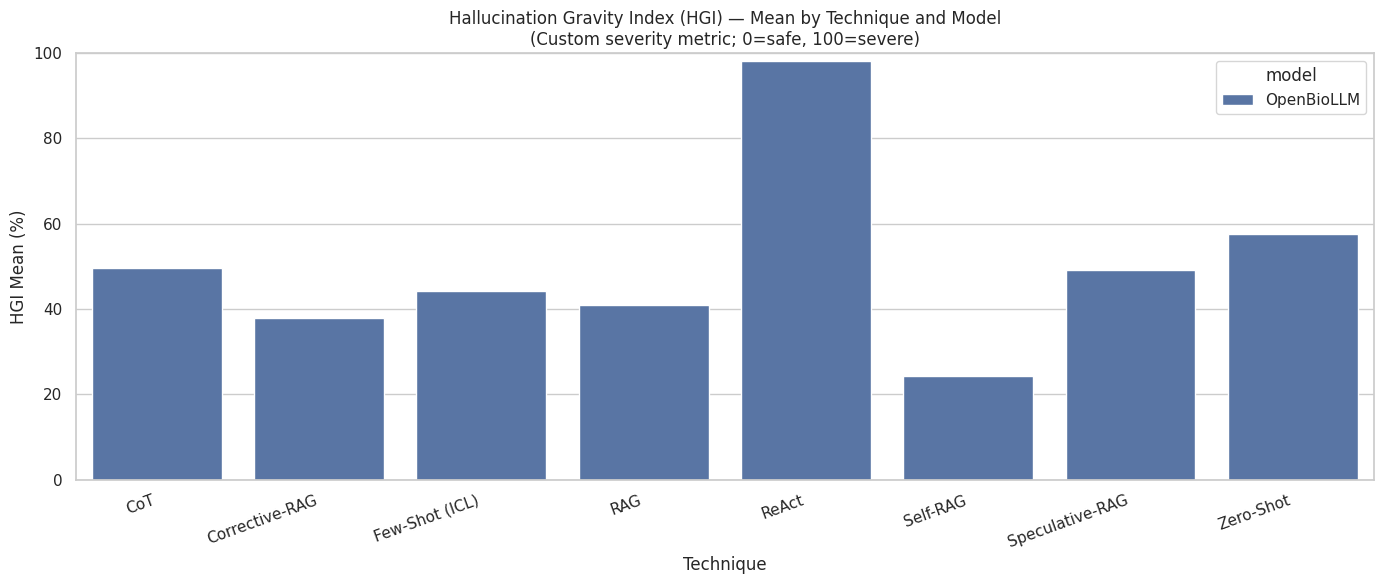

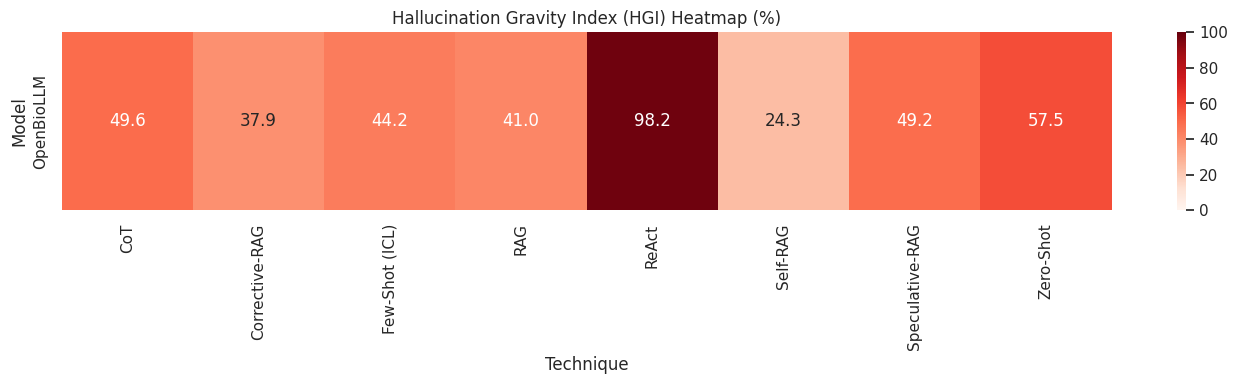

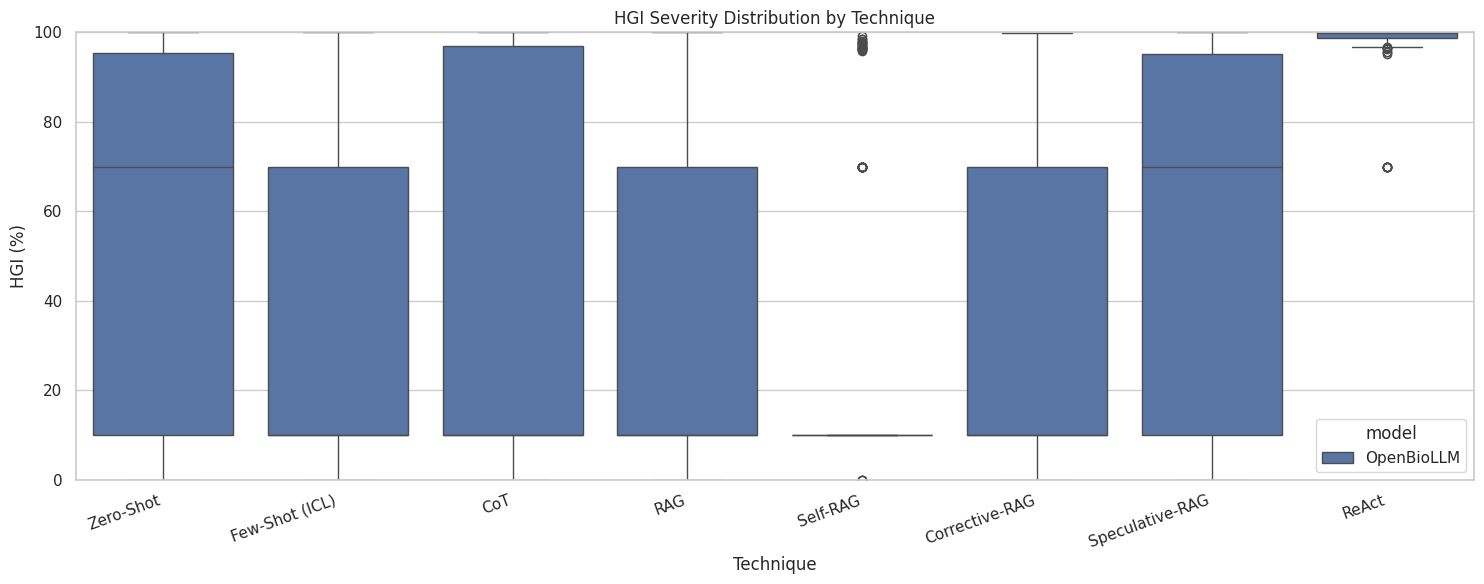

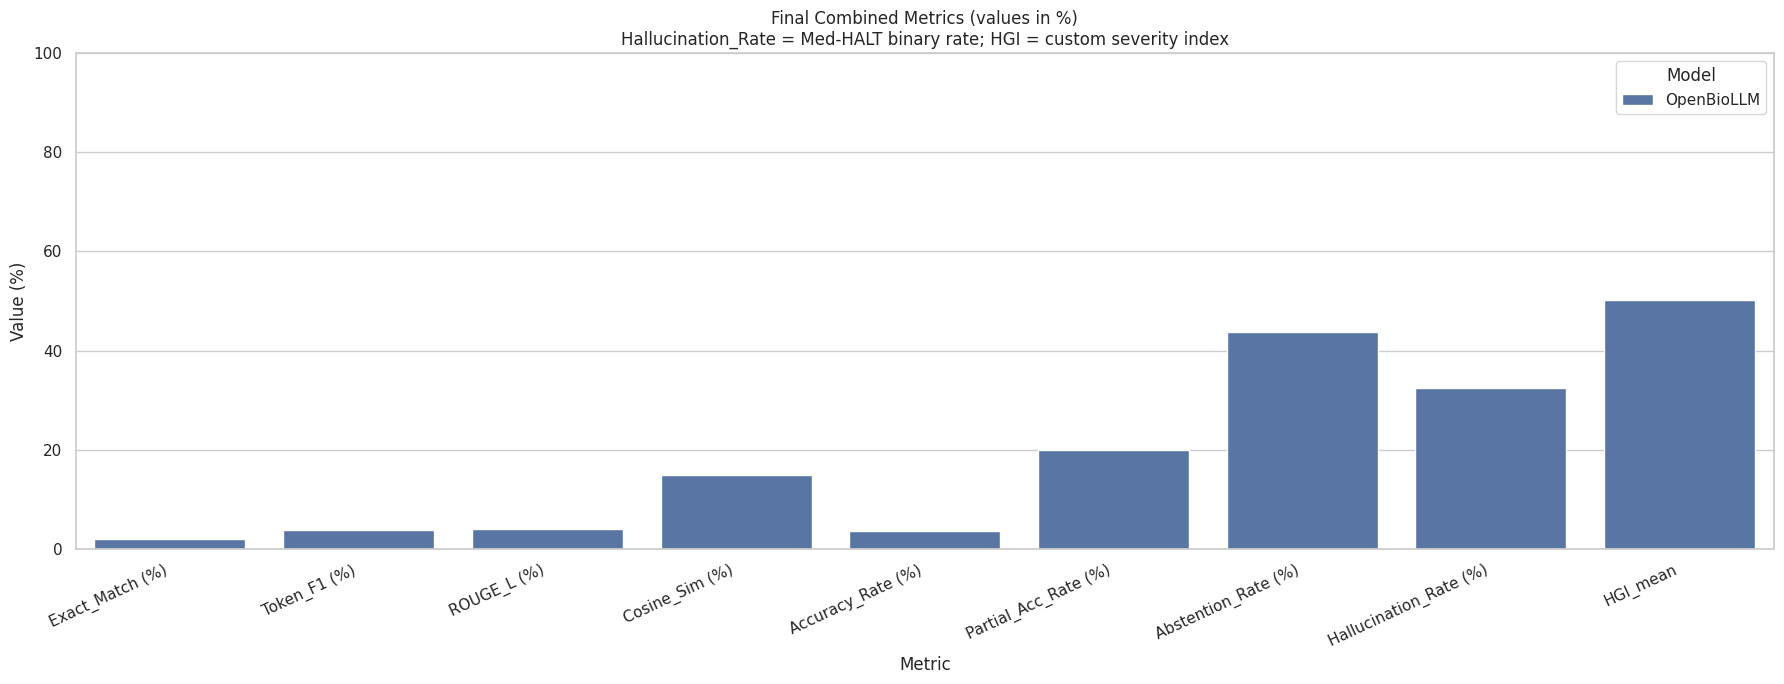


Saved plots:
  /kaggle/working/output/plot_hgi_bar.png
  /kaggle/working/output/plot_hgi_heatmap.png
  /kaggle/working/output/plot_hgi_distribution.png
  /kaggle/working/output/plot_final_combined_metrics_with_hgi.png


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_results' not in globals() or 'df_details' not in globals():
    raise ValueError("Please run the evaluation cells first so df_results and df_details are available.")


def _clip01(x):
    try:
        return float(np.clip(float(x), 0.0, 1.0))
    except Exception:
        return 0.0


def hallucination_gravity(row):
    """
    Hallucination Gravity Index (HGI) — custom severity metric.
    NOTE: This is NOT from any standard benchmark paper.
    Grades: 0.00=correct, 0.10=abstention, 0.35-0.70=partial, 0.70-1.00=hallucination.
    """
    category = str(row.get('category', '')).strip().lower()
    em  = _clip01(row.get('exact_match', 0.0))
    f1  = _clip01(row.get('token_f1', 0.0))
    cos = _clip01(row.get('cosine_sim', row.get('cosine_similarity', 0.0)))

    if category == 'correct':
        return 0.00
    if category == 'abstention':
        return 0.10
    if category == 'partially_correct':
        score = 0.35 + 0.35 * (1.0 - cos) + 0.30 * (1.0 - f1)
        return float(np.clip(score, 0.35, 0.70))
    # hallucination
    score = 0.70 + 0.20 * (1.0 - cos) + 0.10 * (1.0 - em)
    return float(np.clip(score, 0.70, 1.00))


# ------------------------------------------------------------------
# Build severity-enhanced detail table
# ------------------------------------------------------------------
df_details_hg = df_details.copy()
df_details_hg['hallucination_gravity'] = df_details_hg.apply(hallucination_gravity, axis=1)
df_details_hg['hallucination_gravity'] *= 100   # scale to 0–100 %

# ------------------------------------------------------------------
# Aggregate per model × technique
# ------------------------------------------------------------------
summary_gravity = (
    df_details_hg
    .groupby(['model', 'technique'], as_index=False)
    .agg(
        HGI_mean   = ('hallucination_gravity', 'mean'),
        HGI_median = ('hallucination_gravity', 'median'),
        HGI_std    = ('hallucination_gravity', 'std'),
        Cases      = ('hallucination_gravity', 'count'),
    )
)
summary_gravity['HGI_std'] = summary_gravity['HGI_std'].fillna(0.0)

# Merge with aggregated results table
if 'Model' in df_results.columns and 'Technique' in df_results.columns:
    df_results_hg = df_results.merge(
        summary_gravity,
        left_on=['Model', 'Technique'],
        right_on=['model', 'technique'],
        how='left',
    ).drop(columns=['model', 'technique'])
else:
    df_results_hg = df_results.copy()

print('=' * 100)
print('HGI SUMMARY  (values in %)')
print('=' * 100)
display(summary_gravity.sort_values(['model', 'HGI_mean', 'technique']))

print('\n' + '=' * 100)
print('AGGREGATED RESULTS WITH HGI')
print('=' * 100)
display(df_results_hg)

# ------------------------------------------------------------------
# Save CSV artifacts
# ------------------------------------------------------------------
out_dir = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else '.'
os.makedirs(out_dir, exist_ok=True)

csv_details_hg = os.path.join(out_dir, 'phase3_details_with_gravity.csv')
csv_summary_hg = os.path.join(out_dir, 'phase3_hgi_summary.csv')
csv_results_hg = os.path.join(out_dir, 'phase3_results_with_hgi.csv')

df_details_hg.to_csv(csv_details_hg,  index=False)
summary_gravity.to_csv(csv_summary_hg, index=False)
df_results_hg.to_csv(csv_results_hg,  index=False)

print('\nSaved CSV files:')
print(f'  {csv_details_hg}')
print(f'  {csv_summary_hg}')
print(f'  {csv_results_hg}')

# ------------------------------------------------------------------
# Plot 1 — HGI bar chart (mean per technique / model)
# ------------------------------------------------------------------
plt.figure(figsize=(14, 6))
sns.barplot(data=summary_gravity, x='technique', y='HGI_mean', hue='model')
plt.title('Hallucination Gravity Index (HGI) — Mean by Technique and Model\n(Custom severity metric; 0=safe, 100=severe)')
plt.xlabel('Technique')
plt.ylabel('HGI Mean (%)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plot1 = os.path.join(out_dir, 'plot_hgi_bar.png')
plt.savefig(plot1, dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Plot 2 — HGI heatmap (model × technique)
# ------------------------------------------------------------------
pivot_hgi = summary_gravity.pivot(index='model', columns='technique', values='HGI_mean')
plt.figure(figsize=(14, 4))
sns.heatmap(pivot_hgi, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100)
plt.title('Hallucination Gravity Index (HGI) Heatmap (%)')
plt.xlabel('Technique')
plt.ylabel('Model')
plt.tight_layout()
plot2 = os.path.join(out_dir, 'plot_hgi_heatmap.png')
plt.savefig(plot2, dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Plot 3 — HGI distribution by technique
# ------------------------------------------------------------------
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_details_hg, x='technique', y='hallucination_gravity', hue='model')
plt.title('HGI Severity Distribution by Technique')
plt.xlabel('Technique')
plt.ylabel('HGI (%)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plot3 = os.path.join(out_dir, 'plot_hgi_distribution.png')
plt.savefig(plot3, dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Plot 4 — Combined final metrics bar chart
# Med-HALT 4-category rates + lexical metrics + HGI
# ------------------------------------------------------------------
df_plot = pd.read_csv(csv_results_hg)

candidate_metrics = [
    'Exact_Match (%)',
    'Token_F1 (%)',
    'ROUGE_L (%)',
    'Cosine_Sim (%)',
    'Accuracy_Rate (%)',
    'Partial_Acc_Rate (%)',
    'Abstention_Rate (%)',
    'Hallucination_Rate (%)',  # binary Med-HALT definition
    'HGI_mean',                # custom severity (not from literature)
]
plot_metrics = [m for m in candidate_metrics if m in df_plot.columns]

melted = df_plot.melt(
    id_vars=['Model', 'Technique'],
    value_vars=plot_metrics,
    var_name='Metric',
    value_name='Value',
)
plt.figure(figsize=(18, 7))
sns.barplot(data=melted, x='Metric', y='Value', hue='Model', errorbar=None)
plt.title('Final Combined Metrics (values in %)\nHallucination_Rate = Med-HALT binary rate; HGI = custom severity index')
plt.xlabel('Metric')
plt.ylabel('Value (%)')
plt.ylim(0, 100)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plot4 = os.path.join(out_dir, 'plot_final_combined_metrics_with_hgi.png')
plt.savefig(plot4, dpi=150, bbox_inches='tight')
plt.show()

print('\nSaved plots:')
print(f'  {plot1}')
print(f'  {plot2}')
print(f'  {plot3}')
print(f'  {plot4}')


## 11) Single-Case Playground

Run **all techniques** on a single custom case across embedding profiles.
Paste your clinical case text in `CUSTOM_TEST_TEXT` and run the cell below.

In [14]:
# Single-case playground: run all techniques across embedding profiles
# Paste your case text below, then run this cell.
CUSTOM_TEST_TEXT = """
35-year-old patient with progressive gait instability, dysarthria, distal muscle wasting,
areflexia, and pes cavus. Family history suggests autosomal recessive inheritance.
""".strip()

TEST_MODEL_KEY = MODELS_TO_TEST[0] if MODELS_TO_TEST else "OpenBioLLM"
TEST_EMBEDDING_PROFILES = (
    EMBEDDING_PROFILES_TO_COMPARE if ENABLE_EMBEDDING_COMPARISON else [DEFAULT_EMBEDDING_PROFILE]
)

# Use all prompt techniques defined in the notebook
TECHNIQUES_TO_RUN = PROMPTS_TO_TEST

if not CUSTOM_TEST_TEXT:
    raise ValueError("Please set CUSTOM_TEST_TEXT to the clinical case you want to test.")

print("=" * 96)
print("SINGLE-CASE TEST")
print("=" * 96)
print(f"Model: {TEST_MODEL_KEY} -> {MODEL_REGISTRY.get(TEST_MODEL_KEY, 'unknown')}")
print(f"Embeddings: {TEST_EMBEDDING_PROFILES}")
print(f"Techniques: {TECHNIQUES_TO_RUN}")
print("Input text:")
print(CUSTOM_TEST_TEXT)
print("=" * 96)

rows = []

for emb_profile in TEST_EMBEDDING_PROFILES:
    print("\n" + "-" * 96)
    print(f"Embedding profile: {emb_profile} ({EMBEDDING_MODEL_REGISTRY.get(emb_profile, 'unknown')})")
    print("-" * 96)

    for technique in TECHNIQUES_TO_RUN:
        # Only run RAG techniques across all embedding profiles;
        # non-RAG techniques only on the default profile.
        if emb_profile != DEFAULT_EMBEDDING_PROFILE and technique not in RAG_RETRIEVAL_TYPES:
            continue

        technique_label = TECHNIQUE_NAMES.get(technique, technique)
        if ENABLE_EMBEDDING_COMPARISON and technique in RAG_RETRIEVAL_TYPES:
            technique_label = f"{technique_label} [{emb_profile}]"

        t0 = time.time()
        try:
            raw_output, _ = process_patient_case(
                CUSTOM_TEST_TEXT,
                prompt_type=technique,
                llm_model=TEST_MODEL_KEY,
                target_val='',
                embedding_profile=emb_profile,
            )
            clean_output = extract_final_diagnosis(raw_output)
            elapsed = time.time() - t0

            rows.append({
                "Model": TEST_MODEL_KEY,
                "Embedding": emb_profile,
                "Technique": technique_label,
                "Prompt_Type": technique,
                "Prediction_Clean": clean_output,
                "Inference_Time_s": elapsed,
                "Prediction_Raw": raw_output,
            })

            print(f"\n[{technique_label}]\nFinal diagnosis: {clean_output}\nTime: {elapsed:.2f}s")
            print("Raw output preview:")
            print(str(raw_output)[:1000])
        except Exception as e:
            elapsed = time.time() - t0
            rows.append({
                "Model": TEST_MODEL_KEY,
                "Embedding": emb_profile,
                "Technique": technique_label,
                "Prompt_Type": technique,
                "Prediction_Clean": "[ERROR]",
                "Inference_Time_s": elapsed,
                "Prediction_Raw": f"Error: {e}",
            })
            print(f"\n[{technique_label}] ERROR: {e}")

single_case_df = pd.DataFrame(rows)
print("\n" + "=" * 96)
print("SUMMARY TABLE")
print("=" * 96)
display(single_case_df[["Model", "Embedding", "Technique", "Prediction_Clean", "Inference_Time_s"]])

single_case_csv = os.path.join(OUTPUT_DIR, "phase3_single_case_outputs.csv")
single_case_df.to_csv(single_case_csv, index=False)
print(f"Saved: {single_case_csv}")

SINGLE-CASE TEST
Model: OpenBioLLM -> aaditya/Llama3-OpenBioLLM-8B
Embeddings: ['biomed']
Techniques: ['zero-shot', 'few-shot', 'cot', 'rag', 'self-rag', 'corrective-rag', 'speculative-rag', 'react']
Input text:
35-year-old patient with progressive gait instability, dysarthria, distal muscle wasting,
areflexia, and pes cavus. Family history suggests autosomal recessive inheritance.

------------------------------------------------------------------------------------------------
Embedding profile: biomed (NeuML/pubmedbert-base-embeddings)
------------------------------------------------------------------------------------------------
Loading model: OpenBioLLM -> aaditya/Llama3-OpenBioLLM-8B
Retrying model load with safetensors=False (PyTorch .bin fallback)...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


[Zero-Shot]
Final diagnosis: Charcot-Marie-Tooth disease
Time: 43.39s
Raw output preview:
Charcot-Marie-Tooth disease

[Few-Shot (ICL)]
Final diagnosis: Ataxia telangiectasia
Time: 2.15s
Raw output preview:
Ataxia telangiectasia


Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[CoT]
Final diagnosis: [Exact Disease Name]
Time: 1.93s
Raw output preview:
[Exact Disease Name]


...


[Corrective-RAG]
Final diagnosis: 
Time: 2.66s
Raw output preview:



Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Speculative-RAG]
Final diagnosis: 
Time: 6.08s
Raw output preview:


[ReAct]
Final diagnosis: diagnosis
Time: 26.76s
Raw output preview:
Final diagnosis: diagnosis

SUMMARY TABLE


,Model,Embedding,Technique,Prediction_Clean,Inference_Time_s
0,OpenBioLLM,biomed,Zero-Shot,Charcot-Marie-Tooth disease,43.387022
1,OpenBioLLM,biomed,Few-Shot (ICL),Ataxia telangiectasia,2.151819
2,OpenBioLLM,biomed,CoT,[Exact Disease Name],1.933850
3,OpenBioLLM,biomed,RAG,,0.673990
4,OpenBioLLM,biomed,Self-RAG,,0.638872
5,OpenBioLLM,biomed,Corrective-RAG,,2.662865
6,OpenBioLLM,biomed,Speculative-RAG,,6.075387
7,OpenBioLLM,biomed,ReAct,diagnosis,26.757734


Saved: /kaggle/working/output/phase3_single_case_outputs.csv


---
## 12. Phenopacket Single-Case Evaluation

Run the phenopacket case with **pre-extracted HPO terms** vs **LLM-guessed HPO**.


In [15]:
# ── Load ALL phenopacket files ────────────────────────────────────────────────
import glob

# On Kaggle, DATA_DIR is the dataset input path; locally you may need to adjust
PHENOPACKET_DIR = DATA_DIR

# Auto-discover all phenopacket JSON files
phenopacket_files = sorted(set(
    glob.glob(os.path.join(PHENOPACKET_DIR, "*_phenopacket.json"))
))

# Fallback: check local data/ folder if nothing found in DATA_DIR
if not phenopacket_files:
    _local = os.path.join(os.path.dirname(PHENOPACKET_DIR), "data")
    phenopacket_files = sorted(set(
        glob.glob(os.path.join(_local, "*_phenopacket.json"))
    ))

# Parse each phenopacket
ALL_PHENOPACKETS = []
for pp_path in phenopacket_files:
    with open(pp_path, "r", encoding="utf-8") as f:
        pp = json.load(f)
    hpo_terms = [
        feat["type"]["label"]
        for feat in pp.get("phenotypicFeatures", [])
        if not feat.get("excluded", False)
    ]
    ALL_PHENOPACKETS.append({
        "id":     pp.get("id", os.path.basename(pp_path)),
        "input":  pp.get("input", ""),
        "target": pp.get("target", ""),
        "hpo":    hpo_terms,
        "path":   pp_path,
    })

print(f"Loaded {len(ALL_PHENOPACKETS)} phenopacket(s):")
for pp in ALL_PHENOPACKETS:
    print(f"  • {pp['id']}  |  HPO: {len(pp['hpo'])} terms  |  Target: {pp['target']}")


Loaded 6 phenopacket(s):
  • phenopacket-NOTE_001  |  HPO: 12 terms  |  Target: Ehlers-Danlos syndrome, hypermobility type
  • phenopacket-NOTE_FR_001  |  HPO: 12 terms  |  Target: Cystic fibrosis
  • phenopacket-NOTE_FR_002  |  HPO: 11 terms  |  Target: Wiskott-Aldrich syndrome
  • phenopacket-NOTE_FR_003  |  HPO: 8 terms  |  Target: X-linked agammaglobulinemia
  • phenopacket-NOTE_FR_004  |  HPO: 12 terms  |  Target: MHC class II deficiency
  • phenopacket-NOTE_FR_005  |  HPO: 6 terms  |  Target: MHC class II deficiency


In [16]:
# ── Multi-phenopacket ablation: Phenopacket HPO vs LLM-guessed HPO ───────────
active_profile = DEFAULT_EMBEDDING_PROFILE
set_active_embedding(active_profile)

techniques = PROMPTS_TO_TEST
pp_results = []

for pp_idx, pp_case in enumerate(ALL_PHENOPACKETS):
    pp_query  = pp_case["input"]
    pp_target = pp_case["target"]
    pp_hpo    = pp_case["hpo"]
    pp_id     = pp_case["id"]

    print(f'\n{"#" * 96}')
    print(f'  PHENOPACKET {pp_idx + 1}/{len(ALL_PHENOPACKETS)}: {pp_id}')
    print(f'  Target : {pp_target}')
    print(f'  HPO    : {len(pp_hpo)} terms')
    print(f'{"#" * 96}')

    for mode_name, hpo_list in [("Phenopacket HPO", pp_hpo), ("LLM-guessed HPO", None)]:
        print('\n' + '=' * 80)
        print(f'  MODE: {mode_name}')
        print('=' * 80)
        ACTIVE_PHENOPACKET_HPO = hpo_list

        for technique in techniques:
            torch.cuda.empty_cache()
            gc.collect()
            label = TECHNIQUE_NAMES.get(technique, technique)
            print(f'\n  --- {label} ({mode_name}) ---')
            t0 = time.time()

            # FIX: was run_inference() which doesn't exist
            prediction = process_patient_case(
                pp_query, technique, MODELS_TO_TEST[0],
                target_val=pp_target, embedding_profile=active_profile,
                hpo_mode=mode_name
            )[0]

            inf_time = time.time() - t0
            diag  = extract_final_diagnosis(prediction)
            em    = compute_exact_match(prediction, pp_target)
            f1    = compute_token_f1(prediction, pp_target)
            cos   = compute_cosine_similarity(prediction, pp_target)
            hallu = detect_hallucination(prediction, pp_target, cos, em_score=em, f1_score=f1)

            # FIX: was compute_hgi() which doesn't exist
            hgi   = compute_hallucination_gravity(em, f1, cos, hallu["confidence_category"])

            pp_results.append({
                "Phenopacket": pp_id, "Mode": mode_name, "Technique": label,
                "Prediction": diag, "Target": pp_target,
                "Exact_Match": em, "Token_F1": f1, "Cosine_Sim": cos,
                "Category": hallu["confidence_category"], "HGI": hgi, "Time_s": inf_time,
            })
            print(f'    Prediction: {diag}')
            print(f'    EM={em:.0f} | F1={f1:.3f} | Cosine={cos:.3f} | {hallu["confidence_category"]}')
            print(f'    Time: {inf_time:.1f}s')

ACTIVE_PHENOPACKET_HPO = None  # Reset

# ── Results ───────────────────────────────────────────────────────────────────
df_pp = pd.DataFrame(pp_results)
print('\n' + '=' * 80)
print('PHENOPACKET ABLATION RESULTS (ALL CASES)')
print('=' * 80)
display(df_pp)

# Aggregated comparison (averaged across all phenopackets)
pivot = df_pp.pivot_table(
    index="Technique", columns="Mode",
    values=["Cosine_Sim", "Exact_Match", "HGI", "Token_F1"],
    aggfunc="mean"
)
print('\n' + '=' * 80)
print('ABLATION COMPARISON (averaged): Phenopacket HPO vs. LLM-guessed HPO')
print('=' * 80)
display(pivot)

# Per-phenopacket breakdown (only shown when multiple cases exist)
if len(ALL_PHENOPACKETS) > 1:
    pivot_per_case = df_pp.pivot_table(
        index=["Phenopacket", "Technique"], columns="Mode",
        values=["Cosine_Sim", "Exact_Match", "HGI"],
        aggfunc="mean"
    )
    print('\n' + '=' * 80)
    print('PER-PHENOPACKET BREAKDOWN')
    print('=' * 80)
    display(pivot_per_case)

out_csv = os.path.join(OUTPUT_DIR, 'phenopacket_ablation_results.csv')
df_pp.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')


Active embedding -> profile: biomed | model: NeuML/pubmedbert-base-embeddings | index_size: 130316

################################################################################################
  PHENOPACKET 1/6: phenopacket-NOTE_001
  Target : Ehlers-Danlos syndrome, hypermobility type
  HPO    : 12 terms
################################################################################################

  MODE: Phenopacket HPO

  --- Zero-Shot (Phenopacket HPO) ---
    Prediction: Ehlers-Danlos Syndrome, hypermobility type (hEDS)
    EM=1 | F1=1.000 | Cosine=1.000 | correct
    Time: 5.3s

  --- Few-Shot (ICL) (Phenopacket HPO) ---
    Prediction: Ehlers-Danlos Syndrome, hypermobility type (hEDS)
    EM=1 | F1=1.000 | Cosine=1.000 | correct
    Time: 6.4s

  --- CoT (Phenopacket HPO) ---
    Prediction: Ehlers-Danlos Syndrome, hypermobility type (hEDS)
    EM=1 | F1=1.000 | Cosine=1.000 | correct
    Time: 5.7s

  --- RAG (Phenopacket HPO) ---
    Prediction: 
    EM=0 | F1=0.000 | C

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



  --- RAG (LLM-guessed HPO) ---
    Prediction: 
    EM=0 | F1=0.000 | Cosine=0.061 | hallucination
    Time: 4.2s


Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



  --- Self-RAG (LLM-guessed HPO) ---
    Prediction: 
    EM=0 | F1=0.000 | Cosine=0.061 | hallucination
    Time: 3.2s


...


ABLATION COMPARISON (averaged): Phenopacket HPO vs. LLM-guessed HPO


Cosine_Sim                     Exact_Match  \
Mode            LLM-guessed HPO Phenopacket HPO LLM-guessed HPO   
Technique                                                         
CoT                    0.686083        0.682507        0.666667   
Corrective-RAG         0.058342        0.058342        0.000000   
Few-Shot (ICL)         0.440818        0.421557        0.333333   
RAG                    0.058342        0.058342        0.000000   
ReAct                  0.058342        0.058342        0.000000   
Self-RAG               0.058342        0.058342        0.000000   
Speculative-RAG        0.058342        0.058342        0.000000   
Zero-Shot              0.792940        0.744672        0.666667   

                                            HGI                  \
Mode            Phenopacket HPO LLM-guessed HPO Phenopacket HPO   
Technique                                                         
CoT                    0.666667        0.282708        0.282708   
Corrective-RAG         0.000000        0.988332        0.988332   
Few-Shot (ICL)         0.333333        0.353688        0.211277   
RAG                    0.000000        0.988332        0.988332   
ReAct                  0.000000        0.988332        0.988332   
Self-RAG               0.000000        0.988332        0.988332   
Speculative-RAG        0.000000        0.988332        0.988332   
Zero-Shot              0.666667        0.233333        0.276151   

                       Token_F1                  
Mode            LLM-guessed HPO Phenopacket HPO  
Technique                                        
CoT                    0.583333        0.583333  
Corrective-RAG         0.000000        0.000000  
Few-Shot (ICL)         0.333333        0.333333  
RAG                    0.000000        0.000000  
ReAct                  0.000000        0.000000  
Self-RAG               0.000000        0.000000  
Speculative-RAG        0.000000        0.000000  
Zero-Shot              0.625000        0.625000


PER-PHENOPACKET BREAKDOWN


Cosine_Sim                  \
Mode                                    LLM-guessed HPO Phenopacket HPO   
Phenopacket             Technique                                         
phenopacket-NOTE_001    CoT                    1.000000        1.000000   
                        Corrective-RAG         0.060972        0.060972   
                        Few-Shot (ICL)         1.000000        1.000000   
                        RAG                    0.060972        0.060972   
                        ReAct                  0.060972        0.060972   
                        Self-RAG               0.060972        0.060972   
                        Speculative-RAG        0.060972        0.060972   
                        Zero-Shot              1.000000        1.000000   
phenopacket-NOTE_FR_001 CoT                    1.000000        1.000000   
                        Corrective-RAG         0.106606        0.106606   
                        Few-Shot (ICL)         0.173865        0.112102   
                        RAG                    0.106606        0.106606   
                        ReAct                  0.106606        0.106606   
                        Self-RAG               0.106606        0.106606   
                        Speculative-RAG        0.106606        0.106606   
                        Zero-Shot              1.000000        1.000000   
phenopacket-NOTE_FR_002 CoT                    1.000000        1.000000   
                        Corrective-RAG         0.099659        0.099659   
                        Few-Shot (ICL)         1.000000        1.000000   
                        RAG                    0.099659        0.099659   
                        ReAct                  0.099659        0.099659   
                        Self-RAG               0.099659        0.099659   
                        Speculative-RAG        0.099659        0.099659   
                        Zero-Shot              1.000000        1.000000   
phenopacket-NOTE_FR_003 CoT                    0.649147        0.649147   
                        Corrective-RAG         0.016548        0.016548   
                        Few-Shot (ICL)         0.098015        0.098015   
                        RAG                    0.016548        0.016548   
                        ReAct                  0.016548        0.016548   
                        Self-RAG               0.016548        0.016548   
                        Speculative-RAG        0.016548        0.016548   
                        Zero-Shot              0.842644        0.842644   
phenopacket-NOTE_FR_004 CoT                    0.448576        0.018774   
                        Corrective-RAG         0.033132        0.033132   
                        Few-Shot (ICL)         0.215482        0.161681   
                        RAG                    0.033132        0.033132   
                        ReAct                  0.033132        0.033132   
                        Self-RAG               0.033132        0.033132   
                        Speculative-RAG        0.033132        0.033132   
                        Zero-Shot              0.429700        0.215482   
phenopacket-NOTE_FR_005 CoT                    0.018774        0.427119   
                        Corrective-RAG         0.033132        0.033132   
                        Few-Shot (ICL)         0.157546        0.157546   
                        RAG                    0.033132        0.033132   
                        ReAct                  0.033132        0.033132   
                        Self-RAG               0.033132        0.033132   
                        Speculative-RAG        0.033132        0.033132   
                        Zero-Shot              0.485293        0.409906   

                                            Exact_Match                  \
Mode                                    LLM-guessed HPO Phenopacket HPO   
Phenopacket             Technique                                    

Saved: /kaggle/working/output/phenopacket_ablation_results.csv
